# Travel Mode Prediction in London: A Comparative Study of Encoding Strategies and Machine Learning Models

## Preparation

- [Github link](https://github.com/PeiyaoPearl/CASA0006-Data-Science-for-Spatial-Systems-/tree/main/Assessments)

- Number of words: 1551

- Runtime: 33 minutes (*Memory 10 GB, CPU Intel i7-10700 CPU @2.90GHz*)

- Coding environment: Developed in VSCode using Python 3.11.0.

- Execution Note: **If running via SDS Docker or other Jupyter environments**, the kernel may crash ("Kernel Died") due to memory constraints. The dataset contains 220,183 records, and operations like SMOTE oversampling require significant RAM.

- License: this notebook is made available under the [Creative Commons Attribution license](https://creativecommons.org/licenses/by/4.0/) .

- Additional library:
    - `watermark`: For versioning and reproducibility.
    - `xgboost`: For high-performance gradient boosting.
    - `shap`: For model interpretability and feature importance.
    - `tensorflow`: For deep learning and Entity Embedding implementation.
    - `missingno`: For visual exploratory data analysis of missing values.
    - ......

## Table of contents

1. [Introduction](#Introduction)

1. [Research questions](#Research-questions)

1. [Data](#Data)

1. [Exploratory Data Analysis](#Exploratory-Data-Analysis)

1. [Methodology](#Methodology)

1. [Results](#Results)

1. [Disscussion](#Disscussion)

1. [Conclusion](#Conclusion)

1. [References](#References)

## 1 Introduction

[[ go back to the top ]](#Table-of-contents)

Travel mode choice is a core issue in urban transport planning. It is related to traffic congestion, carbon emissions, and spatial equity. The Mayor’s Transport Strategy (TFL, 2018) sets a target that by 2041, 80% of trips in London will be made by walking, cycling, or public transport. This makes travel mode prediction an urgent need for transport planning and for promoting active travel.

Existing studies show that socio-demographic characteristics, trip attributes (such as distance and purpose), and built environment factors all have effects on travel mode choice (Hillel et al., 2018). At the individual level, car ownership and employment status are strong predictors. At the spatial level, the built environment influences mode choice indirectly by shaping travel distance and accessibility. These effects are often non-linear and may involve threshold patterns that are difficult to capture using traditional linear models.

In recent years, machine learning models such as Random Forest and XGBoost have been widely used in travel mode prediction (Wang et al., 2019). Travel mode prediction relies heavily on categorical features related to individuals and trips. Common encoding methods have limitations. One-hot encoding leads to high-dimensional sparse data, while label encoding introduces artificial ordering, which may reduce model performance (Koushik et al., 2023). Entity embedding uses neural networks to learn low-dimensional continuous representations of categorical variables and has been shown to improve prediction accuracy (Ma and Zhang, 2020). However, systematic comparisons of different encoding methods are still limited.

To address this gap, this study uses the London Travel Demand Survey (LTDS) data from 2014 to 2019. It compares label encoding, one-hot encoding, and entity embedding across three models: Random Forest, XGBoost, and deep neural networks. SHAP analysis is further used to identify key predictors of travel behaviour.

## 2 Research questions

[[ go back to the top ]](#Table-of-contents)

**Primary Research Question**:
To what extent do encoding strategie,models and socio-demographic, trip, and built environment features shape machine learning predictions of individual travel mode choice in London?

**RQ1**: How does model choice compare to encoding strategy in affecting predictive performance in travel mode classification?

**RQ2**: Does entity embedding of categorical variables improve travel mode classification performance compared to label encoding and one-hot encoding?

**RQ3**: Which types of factors (socio-demographic, trip-related, and built environment) most strongly influence travel mode choice?



## 3 Data

[[ go back to the top ]](#Table-of-contents)

### 3.1 Data sources
The data is from 4 datasets.

Table 1. Data sources
| Dataset | Source | Unit | Temporal Coverage |
| :--- | :--- | :--- | :---: |
| London Travel Demand Survey (LTDS) | GitHub (https://github.com/mrborin/casa-Dissertation/tree/main/new%20data) combined with TfL LTDS | Individual trip records | 2014–2019 |
| Population | Office for National Statistics (ONS) | Msoa level (aggregated to borough) | 2019 |
| Public Transport Accessibility Level (PTAL) | Transport for London / ArcGIS Open Data | MSOA level (aggregated to borough) | Current |
| Road length| Department for Transport — Road Length Statistics (RDL) | Borough level (computed) | Current |


### 3.2 Data processing

Data preparation involved three stages: variable standardisation, spatial feature integration, and feature selection.The detailed preprocessing workflow is provided in a separate Notebook available in the GitHub repository: [data preprocessing notebook](https://github.com/PeiyaoPearl/CASA0006-Data-Science-for-Spatial-Systems-/blob/main/Assessments/data_cleaning.ipynb).

**Stage 1: Variable Standardisation (LTDS)**
| Operation | Detail |
| :--- | :--- |
| Column naming | Converted to lowercase with underscores |
| Categorical label cleaning | Stripped numeric prefixes from `car_access`, `household_income`, `journey_purpose`, `ethnicity` (e.g. "1 no car" - "no car") |
| Mode recoding | 25 original modes（such as underground, bus) grouped into 4 modes: walk, cycle, car, pt |
| Geographic filtering | Removed records with origin borough outside Greater London (outside M25, unknown, missing); retained 32 boroughs and City of London |

**Stage 2: Spatial Feature Integration**

| Variable | Source | Aggregation Method |
| :--- | :--- | :--- |
| `borough_mean_ptal` | PTAL at MSOA level | Mean of `mean_AI` per borough |
| `borough_pop_density` | ONS population density at MSOA level | Mean of persons/km² per borough |
| `road_density` | DfT road length (RDL) at borough level | Total road length ÷ total borough area (km²) |



**Stage 3: Feature Selection and Export**

| Category | Variables | Count |
| :--- | :--- | :---: |
| Target | `mode` | 1 |
| Trip attributes | `distance_(km)`, `journey_purpose`, `trip_start_time_period` | 3 |
| Socio-demographic | `gender`, `age`, `car_access`, `working_status`, `household_income`, `disability`, `ethnicity`, `household_structure` | 8 |
| Built environment | `borough_mean_ptal`, `borough_pop_density`, `road_density` | 3 |
| **Total** | | **15** |


### 3.3 Data description

The subscript displays all 15 variables in this study.

Table 5. Data description

| Variable | Type | Description |
| :--- | :--- | :--- |
| **Indepedent variables** | | |
| `mode` | Categorical | Travel mode: car, public transport, walk, cycle |
| **Trip Attributes (3)** | | |
| `distance_(km)` | Continuous | One-way trip distance in kilometres |
| `journey_purpose` | Categorical | Purpose of trip: usual workplace, education, shopping, leisure, other, home |
| `trip_start_time_period` | Categorical | Departure time band: early morning, AM peak, interpeak, PM peak, evening, night |
| **Socio-demographic (8)** | | |
| `gender` | Categorical | Gender of traveller: female, male |
| `age` | Continuous | Age of traveller in years |
| `car_access` | Categorical | Household car availability: no car, one car, two or more cars |
| `working_status` | Categorical | Employment status: full-time, part-time, not working, retired, student, under 16 |
| `household_income` | Ordinal | Annual household income band, ranging from <£5,000 to >£100,000 |
| `disability` | Categorical | Whether the traveller has a disability: disabled, not disabled |
| `ethnicity` | Categorical | Ethnic group: white, mixed/other, Asian, Black, refused |
| `household_structure` | Categorical | Household composition: couple with children, couple without children, lone parent, single adult, single pensioner, other |
| **Built Environment (3)** | | |
| `borough_mean_ptal` | Continuous | Mean Public Transport Accessibility Level (PTAL) of the origin borough |
| `borough_pop_density` | Continuous | Mean population density of the origin borough (persons/km²) |
| `road_density` | Continuous | Total road length divided by borough area (km/km²) |

## 4 Exploratory Data Analysis

### 4.1 Data overview

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2. Load CSV
url = "https://raw.githubusercontent.com/PeiyaoPearl/CASA0006-Data-Science-for-Spatial-Systems-/refs/heads/main/Assessments/data/Ltds_clean.csv"
df = pd.read_csv(url)

# Count the number of records each year
year_counts = df['year'].value_counts().sort_index()

print("Total trip records per year:")
print(year_counts)

# Calculate percentage
year_percentage = df['year'].value_counts(normalize=True).sort_index() * 100
print("\nPercentage per year (%):")
print(year_percentage.round(2))

# Drop the specified columns including year
columns_to_drop = ['unique_trip_id', 'origin_borough', 'year']
df = df.drop(columns=columns_to_drop)

# Check the number of NaN values for each column in the entire table
nan_counts = df.isnull().sum()


print("--- Missing Value Statistics (Total NaN Counts) ---")
print(nan_counts)

# Set display resolution
pd.set_option('display.float_format', lambda x: '%.2f' % x)

def generate_academic_table(df):
    results = []

    # --- A. Dependent Variable (mode) ---
    results.append({'Variable': 'Dependent variable', 'Proportion/Mean': '', 'SD': ''})
    counts = df['mode'].value_counts(normalize=True) * 100
    for category, prop in counts.items():
        results.append({'Variable': f'  {category} (%)', 'Proportion/Mean': prop, 'SD': '-'})

    # --- B. Independent Variables (Numerical) ---
    results.append({'Variable': 'Independent variables (Numerical)', 'Proportion/Mean': '', 'SD': ''})
    num_features = {
        'distance_(km)': 'Trip distance (km)',
        'age': 'Age (years)',
        'borough_mean_ptal': 'PTAL Score',
        'road_density': 'Road density (km/km²)'
    }
    
    for col, label in num_features.items():
        if col in df.columns:
            mean_val = df[col].mean()
            sd_val = df[col].std()
            results.append({'Variable': f'  {label}', 'Proportion/Mean': mean_val, 'SD': sd_val})

    # --- C. Independent Variables (Categorical) ---
    cat_features = {
        'gender': 'Gender (%)',
        'household_income': 'Household income (%)',
        'household_structure': 'Household_structure (%)',
        'working_status': 'Employment status (%)'
    }

    for col, label in cat_features.items():
        if col in df.columns:
            results.append({'Variable': label, 'Proportion/Mean': '', 'SD': ''})
            if df[col].isnull().all():
                results.append({'Variable': f'  {col} (Data Missing/NaN)', 'Proportion/Mean': 0, 'SD': ''})
                continue
                
            counts = df[col].value_counts(normalize=True).sort_index() * 100
            for category, prop in counts.items():
                results.append({'Variable': f'  {category}', 'Proportion/Mean': prop, 'SD': ''})

    return pd.DataFrame(results)

final_table = generate_academic_table(df)
print(f"Table 6. Descriptive statistics for variables (N={len(df)})")
display(final_table)

final_table.to_csv('Table_Descriptive_Statistics.csv', index=False, encoding='utf-8-sig')


Total trip records per year:
year
2014    36327
2015    39066
2016    36663
2017    35375
2018    35626
2019    37126
Name: count, dtype: int64

Percentage per year (%):
year
2014    16.50
2015    17.74
2016    16.65
2017    16.07
2018    16.18
2019    16.86
Name: proportion, dtype: float64
--- Missing Value Statistics (Total NaN Counts) ---
mode                      0
distance_(km)             0
journey_purpose           0
trip_start_time_period    0
gender                    0
age                       0
car_access                0
working_status            0
household_income          0
disability                0
ethnicity                 0
household_structure       0
borough_mean_ptal         0
borough_pop_density       0
road_density              0
dtype: int64
Table 6. Descriptive statistics for variables (N=220183)


,Variable,Proportion/Mean,SD
0,Dependent variable,,
1,car (%),35.29,-
2,walk (%),32.96,-
3,pt (%),29.19,-
4,cycle (%),2.56,-
5,Independent variables (Numerical),,
6,Trip distance (km),4.96,14.46
7,Age (years),40.07,19.80
8,PTAL Score,14.61,11.80
9,Road density (km/km²),11.08,3.03


#### 4.2 Variables distribution patterns
EDA shows clear travel behaviour patterns. Car (35.3%) and walking (33.0%) dominate, followed by public transport (29.2%), while cycling is very limited (2.6%), indicating a strong class imbalance.

Socio-demographic factors are key drivers. Car access strongly increases car use, while lower-income groups rely more on public transport and walking.

Trip attributes also matter. Distance clearly differentiates modes, with walking for short trips and car/PT for longer trips. Journey purpose further shapes behaviour.

Built environment variables have weaker effects. Higher PTAL increases PT use and reduces car reliance, while road density shows limited discrimination.

Overall, travel behaviour is mainly driven by individual and trip factors, with the built environment playing a secondary role.



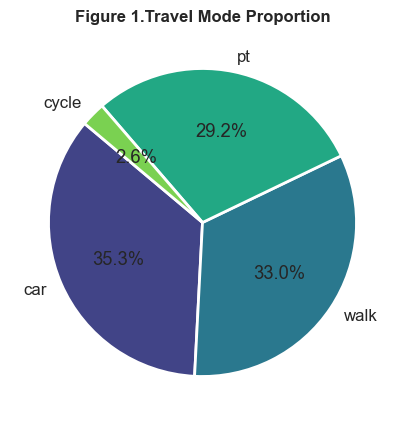

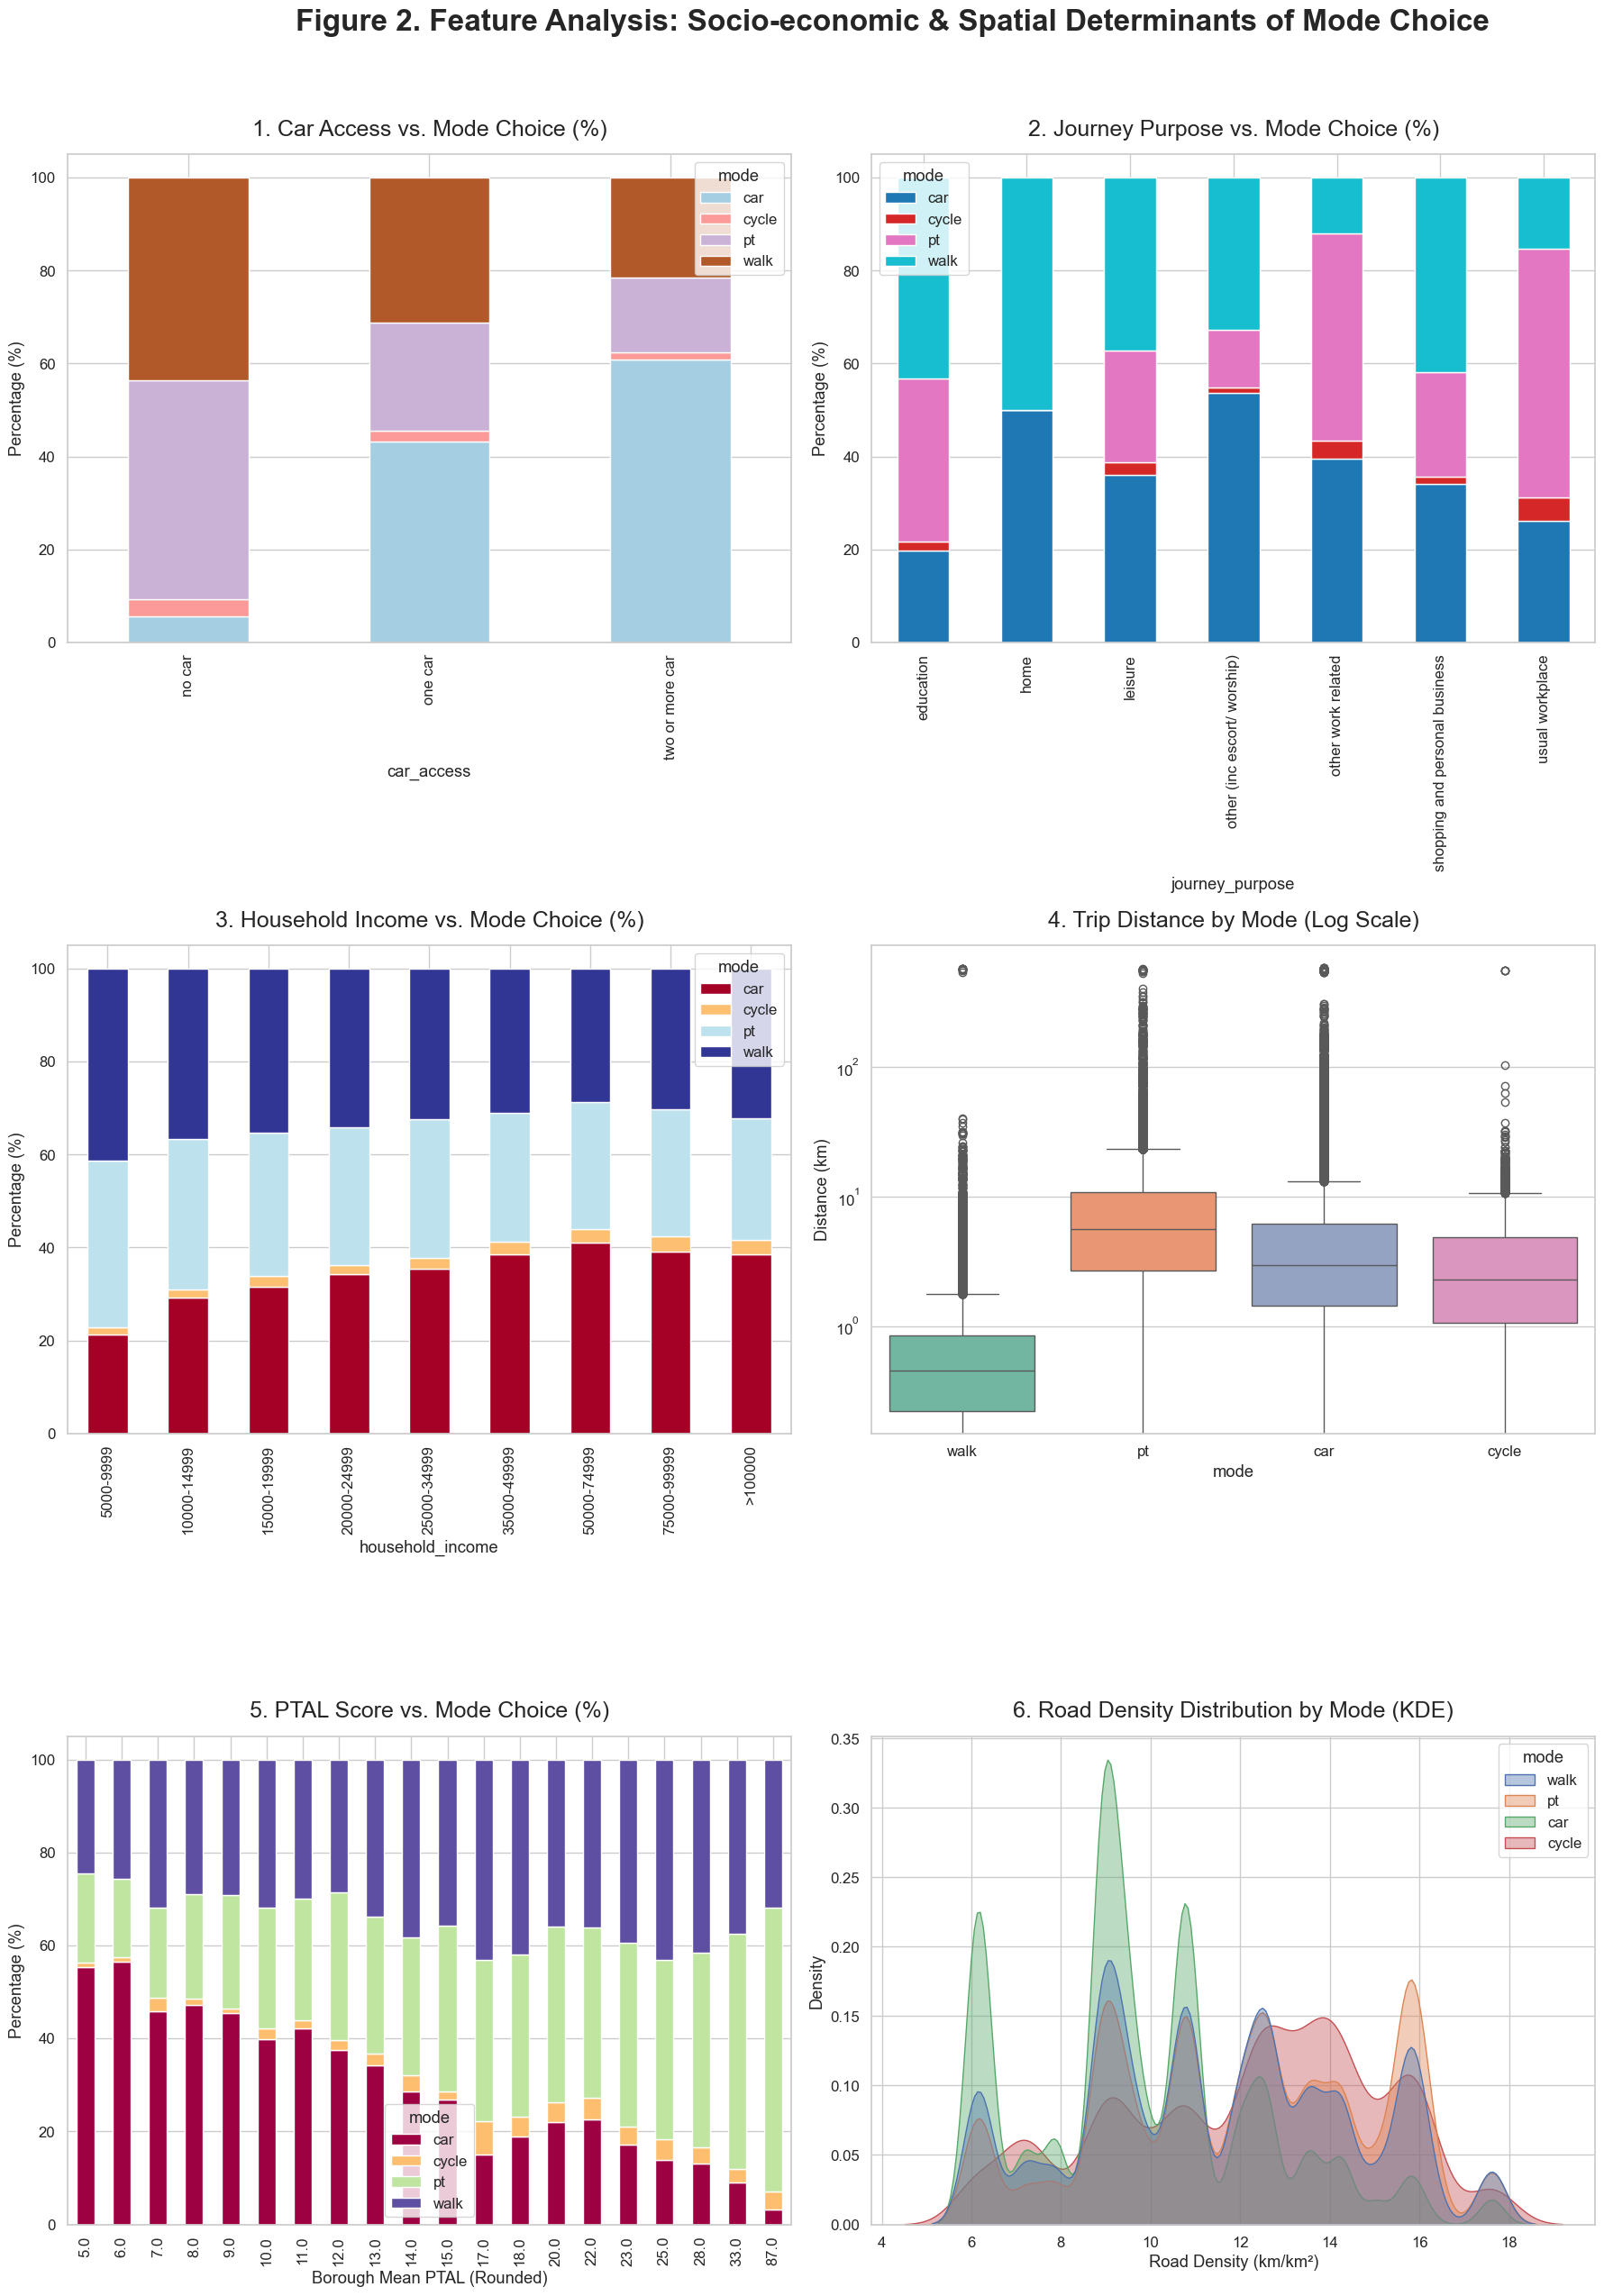

In [19]:
plt.figure(figsize=(5, 5))
mode_counts = df['mode'].value_counts()
plt.pie(mode_counts, labels=mode_counts.index, autopct='%1.1f%%', 
        startangle=140, colors=sns.color_palette("viridis", len(mode_counts)),
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Figure 1.Travel Mode Proportion', fontsize=12, fontweight='bold')
plt.show()

import warnings
warnings.filterwarnings("ignore")

# Ensure column is string type before parsing
df['household_income'] = df['household_income'].astype(str)


def clean_income(val):
    """Map raw income strings to standardised ordinal bands."""
    s = str(val).replace('£', '').replace(',', '').strip().lower()

    if 'nan' in s or 'unknown' in s or s == '':
        return 'Unknown'
    if '100000' in s: return '>100000'
    if '75000' in s: return '75000-99999'
    if '50000' in s: return '50000-74999'
    if '35000' in s: return '35000-49999'
    if '25000' in s: return '25000-34999'
    if '20000' in s: return '20000-24999'
    if '15000' in s: return '15000-19999'
    if '10000' in s: return '10000-14999'
    if '5000' in s: return '5000-9999'
    if 'less than' in s or '0 - 4' in s or 'under' in s: return '<5000'
    return 'Unknown'


df['household_income'] = df['household_income'].apply(clean_income)

# Store as ordered categorical to preserve ordinal structure
income_order = ['<5000', '5000-9999', '10000-14999', '15000-19999',
                '20000-24999', '25000-34999', '35000-49999',
                '50000-74999', '75000-99999', '>100000', 'Unknown']

df['household_income'] = pd.Categorical(df['household_income'],
                                        categories=income_order,
                                        ordered=True)


# Plot styling
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams['font.family'] = 'sans-serif'

# Reapply income ordering to preserve ordinal sequence in plots
income_order = ['5000-9999', '10000-14999', '15000-19999', '20000-24999',
                '25000-34999', '35000-49999', '50000-74999', '75000-99999', '>100000']
df['household_income'] = pd.Categorical(df['household_income'],
                                        categories=income_order, ordered=True)

# Set up 3x2 grid for feature exploration
fig, axes = plt.subplots(3, 2, figsize=(20, 26))
fig.suptitle('Figure 2. Feature Analysis: Socio-economic & Spatial Determinants of Mode Choice',
             fontsize=24, fontweight='bold', y=0.98)

# Row 1: Core predictors
car_cross = pd.crosstab(df['car_access'], df['mode'], normalize='index') * 100
car_cross.plot(kind='bar', stacked=True, ax=axes[0, 0], colormap='Paired', edgecolor='white')
axes[0, 0].set_title('1. Car Access vs. Mode Choice (%)', fontsize=18, pad=15)
axes[0, 0].set_ylabel('Percentage (%)')

purpose_cross = pd.crosstab(df['journey_purpose'], df['mode'], normalize='index') * 100
purpose_cross.plot(kind='bar', stacked=True, ax=axes[0, 1], colormap='tab10', edgecolor='white')
axes[0, 1].set_title('2. Journey Purpose vs. Mode Choice (%)', fontsize=18, pad=15)
axes[0, 1].set_ylabel('Percentage (%)')

# Row 2: Economic and physical constraints
income_cross = pd.crosstab(df['household_income'], df['mode'], normalize='index') * 100
income_cross.plot(kind='bar', stacked=True, ax=axes[1, 0], colormap='RdYlBu', edgecolor='white')
axes[1, 0].set_title('3. Household Income vs. Mode Choice (%)', fontsize=18, pad=15)
axes[1, 0].set_ylabel('Percentage (%)')

# Log scale used due to right-skewed distance distribution
sns.boxplot(data=df, x='mode', y='distance_(km)', ax=axes[1, 1],
            palette='Set2', hue='mode', legend=False)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('4. Trip Distance by Mode (Log Scale)', fontsize=18, pad=15)
axes[1, 1].set_ylabel('Distance (km)')

# Row 3: Built environment
if 'borough_mean_ptal' in df.columns:
    ptal_cross = pd.crosstab(df['borough_mean_ptal'].round(), df['mode'], normalize='index') * 100
    ptal_cross.plot(kind='bar', stacked=True, ax=axes[2, 0], colormap='Spectral', edgecolor='white')
    axes[2, 0].set_title('5. PTAL Score vs. Mode Choice (%)', fontsize=18, pad=15)
    axes[2, 0].set_xlabel('Borough Mean PTAL (Rounded)')
    axes[2, 0].set_ylabel('Percentage (%)')

if 'road_density' in df.columns:
    sns.kdeplot(data=df, x='road_density', hue='mode', fill=True,
                common_norm=False, ax=axes[2, 1], alpha=0.4)
    axes[2, 1].set_title('6. Road Density Distribution by Mode (KDE)', fontsize=18, pad=15)
    axes[2, 1].set_xlabel('Road Density (km/km²)')



plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.show()

### 4.3 Correlation Matrix
The correlation analysis shows generally low correlations among most variables, indicating limited multicollinearity. However, built environment variables exhibit stronger correlations. Road density and population density are highly correlated (0.87), and both are moderately correlated with PTAL, reflecting underlying urban structure and accessibility patterns.



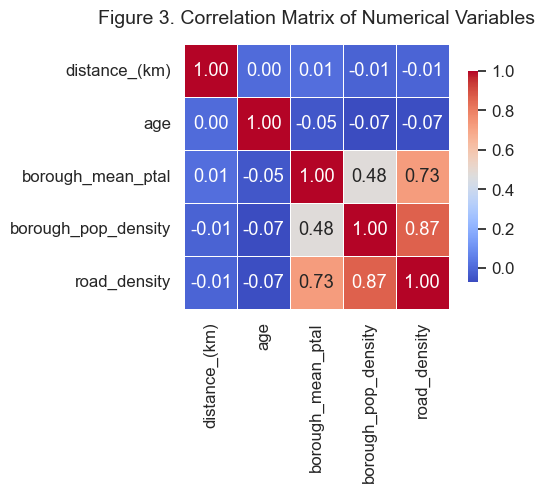

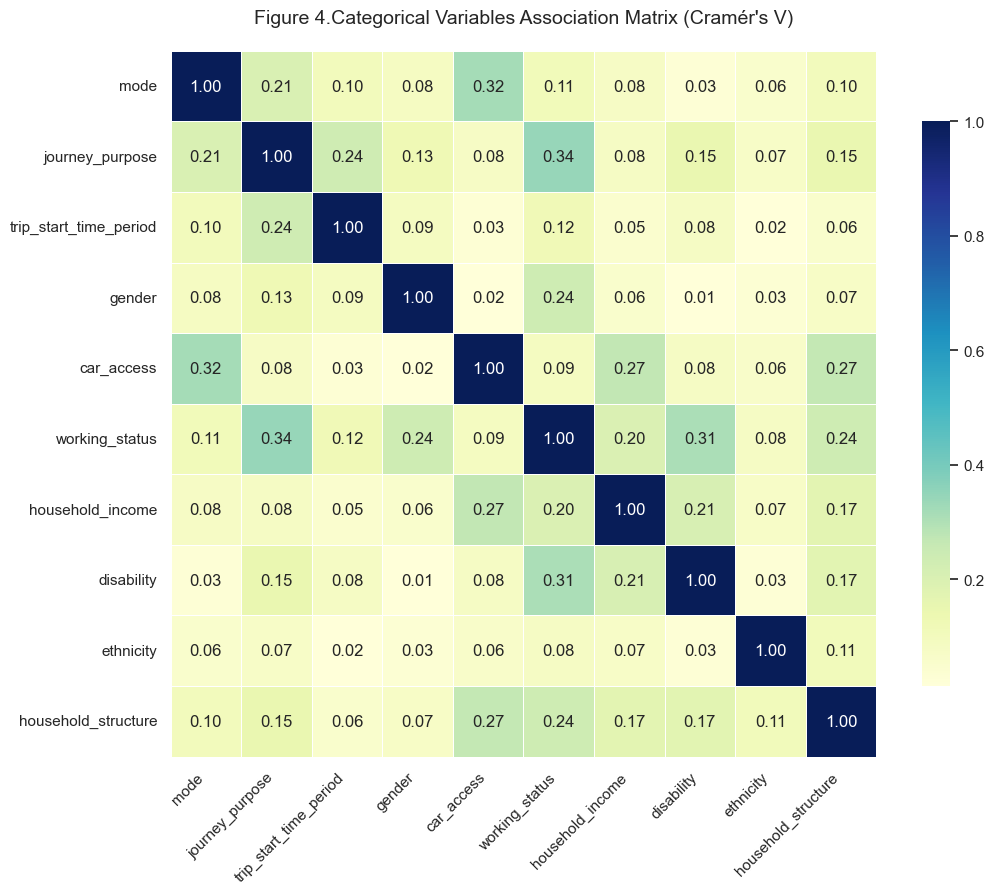

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency

import warnings
warnings.filterwarnings("ignore")

# Pearson correlation for numerical variables
num_cols = ['distance_(km)', 'age', 'borough_mean_ptal',
            'borough_pop_density', 'road_density']

corr = df[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=.5, cbar_kws={"shrink": .8}, square=True)
plt.title('Figure 3. Correlation Matrix of Numerical Variables', fontsize=14, pad=15)
plt.tight_layout()
plt.show()


# Cramér's V for categorical variables
def cramers_v(x, y):
    """Bias-corrected Cramér's V for categorical association."""
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape

    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))


# Select categorical features, excluding high-cardinality identifiers
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
if 'origin_borough' in cat_cols:
    cat_cols.remove('origin_borough')

# Pairwise Cramér's V matrix
v_matrix = np.zeros((len(cat_cols), len(cat_cols)))
for i in range(len(cat_cols)):
    for j in range(len(cat_cols)):
        v_matrix[i, j] = cramers_v(df[cat_cols[i]], df[cat_cols[j]])

df_v = pd.DataFrame(v_matrix, index=cat_cols, columns=cat_cols)

# Plot
sns.set_theme(style="white")
plt.figure(figsize=(11, 9))
sns.heatmap(df_v, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=.5, cbar_kws={"shrink": .8}, square=True)
plt.title("Figure 4.Categorical Variables Association Matrix (Cramér's V)",
          fontsize=14, pad=20)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 5 Methodology

[[ go back to the top ]](#Table-of-contents)

The overall workflow of this study is shown in the figure below.

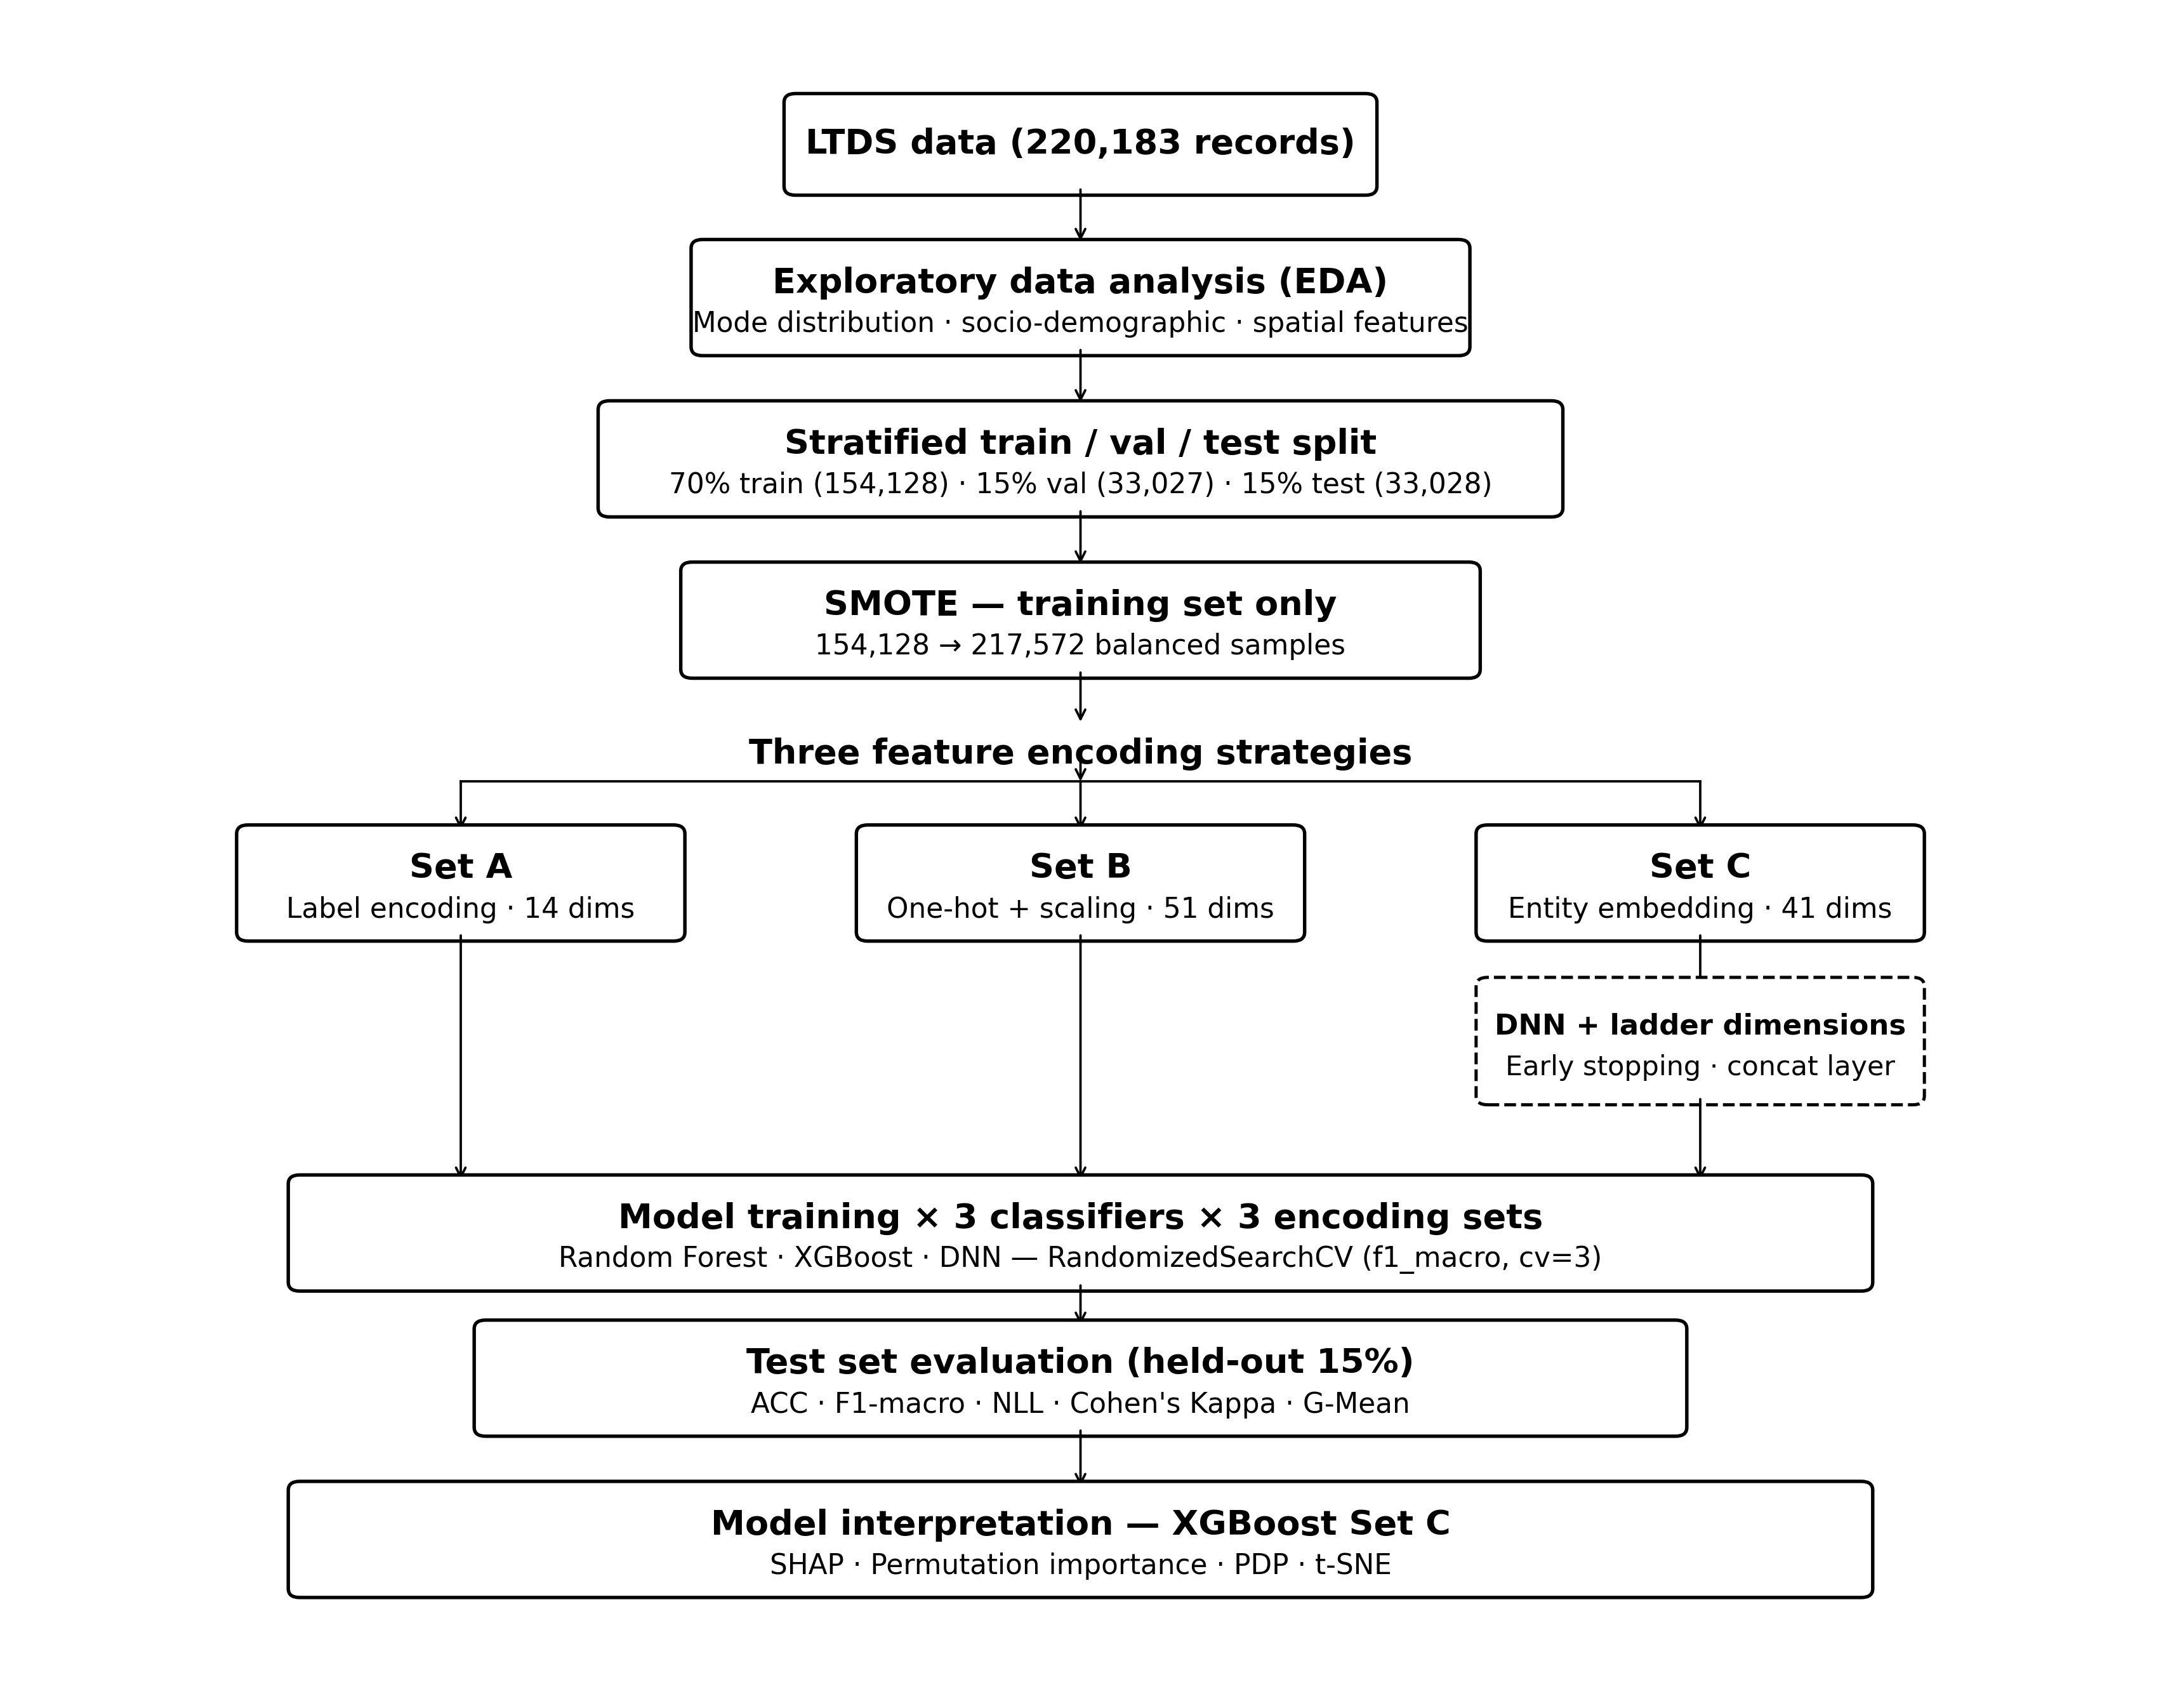

In [5]:
from IPython.display import Image, display
display(Image(filename="image/workflow.png"))

Figure 5. Workflow of the research


### 5.1 Data Splitting and Class Imbalance
The dataset is split into 70% training, 15% validation, and 15% test sets using stratified sampling. Cycling accounts for only 2.6% of trips, indicating severe class imbalance. SMOTE is applied only to the training set to avoid data leakage.


In [6]:
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
exclude_cols = ['unique_trip_id', 'year', 'mode', 'origin_borough']
X = df.drop(columns=[col for col in exclude_cols if col in df.columns]) 
y = df['mode']

# 2. First split: 70% Training, 30% Temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3. Second split: 50% of Temporary set (15% of total) for Validation and Test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# --- Verification ---
print("Data partitioning completed:")
print(f"Train Set: {X_train.shape[0]} rows")
print(f"Val Set:   {X_val.shape[0]} rows")
print(f"Test Set:  {X_test.shape[0]} rows")
print(f"\nCurrent feature list: {X.columns.tolist()}")

Data partitioning completed:
Train Set: 154128 rows
Val Set:   33027 rows
Test Set:  33028 rows

Current feature list: ['distance_(km)', 'journey_purpose', 'trip_start_time_period', 'gender', 'age', 'car_access', 'working_status', 'household_income', 'disability', 'ethnicity', 'household_structure', 'borough_mean_ptal', 'borough_pop_density', 'road_density']


In [7]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

# Variable classifications
cat_features = ['journey_purpose', 'trip_start_time_period', 'gender', 'car_access',
                'working_status', 'household_income', 'disability', 'ethnicity',
                'household_structure']
num_features = ['distance_(km)', 'age', 'borough_mean_ptal',
                'borough_pop_density', 'road_density']

# Label Encoding fitted on the union of train/val/test (avoids unseen categories)
X_train_le = X_train.copy()
X_val_le   = X_val.copy()
X_test_le  = X_test.copy()

label_encoders = {}
vocab_sizes = {}

for col in cat_features:
    le = LabelEncoder()
    all_values = pd.concat([
        X_train[col].astype(str),
        X_val[col].astype(str),
        X_test[col].astype(str)
    ])
    le.fit(all_values)

    X_train_le[col] = le.transform(X_train[col].astype(str))
    X_val_le[col]   = le.transform(X_val[col].astype(str))
    X_test_le[col]  = le.transform(X_test[col].astype(str))

    label_encoders[col] = le
    vocab_sizes[col] = len(le.classes_)

# Treat 'age' as a categorical for embedding purposes (vocab fitted on full data)
le_age = LabelEncoder()
all_age = pd.concat([X_train['age'], X_val['age'], X_test['age']]).astype(str)
le_age.fit(all_age)

X_train_le['age'] = le_age.transform(X_train['age'].astype(str))
X_val_le['age']   = le_age.transform(X_val['age'].astype(str))
X_test_le['age']  = le_age.transform(X_test['age'].astype(str))

label_encoders['age'] = le_age
vocab_sizes['age']    = len(le_age.classes_)

# Encode the target
le_y = LabelEncoder()
y_train_le = le_y.fit_transform(y_train)
y_val_le   = le_y.transform(y_val)
y_test_le  = le_y.transform(y_test)

# SMOTE on the training set only
print("Applying SMOTE to balance the training set...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_le, y_train_le)

# --- Set A: label-encoded (for tree-based models) ---
X_train_set_A = X_train_res
X_val_set_A   = X_val_le
X_test_set_A  = X_test_le

# --- Set B: one-hot + scaled numerical (for DNN baseline) ---
scaler = StandardScaler()
num_train_sc = scaler.fit_transform(X_train_res[num_features])
num_val_sc   = scaler.transform(X_val_le[num_features])
num_test_sc  = scaler.transform(X_test_le[num_features])

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
cat_train_ohe = ohe.fit_transform(X_train_res[cat_features])
cat_val_ohe   = ohe.transform(X_val_le[cat_features])
cat_test_ohe  = ohe.transform(X_test_le[cat_features])

X_train_set_B = np.hstack([num_train_sc, cat_train_ohe])
X_val_set_B   = np.hstack([num_val_sc,   cat_val_ohe])
X_test_set_B  = np.hstack([num_test_sc,  cat_test_ohe])

print("\n--- Data Engineering Summary ---")
print(f"Original training samples:           {len(X_train)}")
print(f"Resampled training samples (SMOTE):  {len(X_train_res)}")
print(f"Set A feature count:                 {X_train_set_A.shape[1]}")
print(f"Set B feature count (one-hot):       {X_train_set_B.shape[1]}")
print(f"\nVocab sizes for embedding layers:")
for col, size in vocab_sizes.items():
    print(f"  {col:<25}: {size}")

Applying SMOTE to balance the training set...

--- Data Engineering Summary ---
Original training samples:           154128
Resampled training samples (SMOTE):  217572
Set A feature count:                 14
Set B feature count (one-hot):       51

Vocab sizes for embedding layers:
  journey_purpose          : 7
  trip_start_time_period   : 6
  gender                   : 2
  car_access               : 3
  working_status           : 6
  household_income         : 9
  disability               : 2
  ethnicity                : 5
  household_structure      : 6
  age                      : 95


### 5.2 Feature Encoding
Three datasets are constructed. Set A uses label encoding with SMOTE, Set B applies one-hot encoding, and Set C adopts entity embedding. In Set C, embedding layers transform categorical variables into low-dimensional dense vectors. These are concatenated with numerical features and passed through fully connected layers for prediction.

In [8]:
import numpy as np
import pandas as pd
from keras.layers import Input, Embedding, Reshape, Concatenate, Dense, Dropout, BatchNormalization
from keras.models import Model
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Categorical features for entity embedding (age included)
cat_to_embed = ['journey_purpose', 'trip_start_time_period', 'gender', 'car_access',
                'working_status', 'household_income', 'disability', 'ethnicity',
                'household_structure', 'age']

num_to_keep = ['distance_(km)', 'borough_mean_ptal',
               'borough_pop_density', 'road_density']


def get_ladder_dim(vocab_size):
    """3-6-10 ladder rule for embedding dimension."""
    v = vocab_size - 1
    if v <= 3:
        return 1
    elif v <= 6:
        return 3
    elif v <= 10:
        return 6
    else:
        return 10


def build_refined_ladder_model(cat_list, num_list, num_classes):
    all_inputs, all_embeddings = [], []

    for col in cat_list:
        # Use globally-fitted vocab size (covers all train/val/test values)
        vocab_size = vocab_sizes[col] + 1
        emb_dim = get_ladder_dim(vocab_size)

        in_layer = Input(shape=(1,), name=f"input_{col}")
        emb_layer = Embedding(vocab_size, emb_dim, name=f"emb_{col}")(in_layer)
        emb_layer = Reshape(target_shape=(emb_dim,))(emb_layer)

        all_inputs.append(in_layer)
        all_embeddings.append(emb_layer)
        print(f"Embedding: {col:<22} | Values: {vocab_size-1:<3} | Dim: {emb_dim}")

    if num_list:
        in_num = Input(shape=(len(num_list),), name="input_numerical")
        all_inputs.append(in_num)
        all_embeddings.append(in_num)
        print(f"Numerical: {num_list} | Dim: {len(num_list)}")

    x = Concatenate(name="set_c_concat")(all_embeddings)

    x_dense = Dense(256, activation='relu')(x)
    x_dense = BatchNormalization()(x_dense)
    x_dense = Dropout(0.3)(x_dense)

    for _ in range(4):
        x_dense = Dense(256, activation='relu')(x_dense)
        x_dense = BatchNormalization()(x_dense)
        x_dense = Dropout(0.3)(x_dense)

    x_dense = Dense(128, activation='relu')(x_dense)
    x_dense = BatchNormalization()(x_dense)
    x_dense = Dropout(0.3)(x_dense)

    output = Dense(num_classes, activation='softmax')(x_dense)
    return Model(inputs=all_inputs, outputs=output)


# Prepare scaled numerical inputs
scaler_C = StandardScaler()
num_train_final = scaler_C.fit_transform(X_train_res[num_to_keep])
num_val_final   = scaler_C.transform(X_val_le[num_to_keep])
num_test_final  = scaler_C.transform(X_test_le[num_to_keep])

X_train_inputs = [X_train_res[col].values for col in cat_to_embed] + [num_train_final]
X_val_inputs   = [X_val_le[col].values   for col in cat_to_embed] + [num_val_final]
X_test_inputs  = [X_test_le[col].values  for col in cat_to_embed] + [num_test_final]

num_classes = len(np.unique(y_train_res))
final_model = build_refined_ladder_model(cat_to_embed, num_to_keep, num_classes)
final_model.compile(optimizer=Adam(0.001),
                    loss='sparse_categorical_crossentropy',
                    metrics=['accuracy'])

final_model.fit(
    X_train_inputs, y_train_res,
    epochs=100, batch_size=2048,
    validation_data=(X_val_inputs, y_val_le),
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4)
    ],
    verbose=1
)

# Extract Set C embeddings
feature_extractor = Model(inputs=final_model.input,
                          outputs=final_model.get_layer('set_c_concat').output)
X_train_C = feature_extractor.predict(X_train_inputs, batch_size=4096)
X_val_C   = feature_extractor.predict(X_val_inputs,   batch_size=4096)
X_test_C  = feature_extractor.predict(X_test_inputs,  batch_size=4096)

print(f"\nFinal Set C dimension: {X_train_C.shape[1]}")

Embedding: journey_purpose        | Values: 7   | Dim: 6
Embedding: trip_start_time_period | Values: 6   | Dim: 3
Embedding: gender                 | Values: 2   | Dim: 1
Embedding: car_access             | Values: 3   | Dim: 1
Embedding: working_status         | Values: 6   | Dim: 3
Embedding: household_income       | Values: 9   | Dim: 6
Embedding: disability             | Values: 2   | Dim: 1
Embedding: ethnicity              | Values: 5   | Dim: 3
Embedding: household_structure    | Values: 6   | Dim: 3
Embedding: age                    | Values: 95  | Dim: 10
Numerical: ['distance_(km)', 'borough_mean_ptal', 'borough_pop_density', 'road_density'] | Dim: 4
Epoch 1/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.4644 - loss: 1.2535 - val_accuracy: 0.0689 - val_loss: 1.6890 - learning_rate: 0.0010
Epoch 2/100
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.6066 - loss: 0.9584 - val_accuracy: 0.4808 - val_loss: 1.5646 - learning_rate: 0.0010
Epoch 3/100
107/107 ━━━

Table 7. Categorical Variables and Entity Embedding Dimensions

| Variable Name | Type | Number of Values | Dimension |
| :--- | :--- | :---: | :---: |
| journey_purpose | nominal | 7 | 6 |
| trip_start_time_period | nominal | 6 | 3 |
| gender | binary | 2 | 1 |
| car_access | nominal | 3 | 1 |
| working_status | nominal | 6 | 3 |
| household_income | ordinal | 9 | 6 |
| disability | binary | 2 | 1 |
| ethnicity | nominal | 5 | 3 |
| household_structure | nominal | 6 | 3 |
| age | ordinal | 95 | 10 |
| **Total Embedding Dimensions** | - | - | **37** |

> **Note**: Embedding dimensions are dynamically assigned based on the unique value count (Vocabulary Size) of each categorical feature, following the defined 3-6-10 ladder logic.

### 5.3 Model Selection
Three models are used: Random Forest and XGBoost as tree-based baselines, and DNN for both embedding learning and classification. Tree-based models capture nonlinear relationships effectively, while DNN enables representation learning.


### 5.4 Training and Evaluation
Nine configurations are tested across models and feature sets. Hyperparameters are tuned using RandomizedSearchCV with stratified 3-fold cross-validation. F1-macro is the main metric to handle class imbalance, alongside ACC, NLL, CK, and G-Mean.

### 5.5 Model Interpretation
The best model (XGBoost Set C) is interpreted using four methods: gain-based feature importance (global importance), SHAP (directional effects), permutation importance (independent contribution), and PDP (nonlinear relationships). t-SNE is used to visualise the structure of learned embeddings.

## 6 Results

[[ go back to the top ]](#Table-of-contents)

### 6.1 Model comparison

Table 8 summarises model performance. Overall, tree-based models outperform DNN across all metrics. XGBoost with embedding features (Set C) achieves the best results, highlighting its strength in modelling  travel data.

Embedding generally yields the best or near-best performance for XGBoost and Random Forest, but improvements over label and one-hot encoding are modest, suggesting tree models are less sensitive to encoding choice. In contrast, DNN performs worse, and although embedding improves its F1, it remains below tree-based models.

Confusion matrices show strong performance for dominant classes (“car” and “walk”), but weaker performance for the minority class (“cycle”), especially for DNN. Models also frequently confuse public transport and walking, likely due to similar short-distance trip characteristics.

Overall, model choice has a greater impact than encoding strategy. While embedding offers some gains, performance is mainly driven by model structure, with XGBoost performing best.

Note: Due to stochastic processes in data splitting, SMOTE oversampling, model training, and hyperparameter tuning, the reported values may vary slightly across different runs. However, the overall performance ranking and main conclusions remain stable.

Table 8. Performance comparison of three classifiers across three encoding strategies.

| Model | Encoding | Accuracy ↑ | F1 ↑ | NLL ↓ | CK ↑ | G-Mean ↑ |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **XGBoost** | **Set C (Embedding)** | **0.8298** | **0.7335** | **0.4800** | **0.7506** | **0.7202** |
| XGBoost | Set A (Label) | 0.8254 | 0.7213 | 0.4885 | 0.7437 | 0.6928 |
| XGBoost | Set B (One-hot) | 0.8244 | 0.7198 | 0.4815 | 0.7428 | 0.7022 |
| **Random Forest** | **Set C (Embedding)** | **0.8177** | **0.7127** | **0.5367** | **0.7329** | **0.6899** |
| Random Forest | Set A (Label) | 0.8164 | 0.7114 | 0.5323 | 0.7308 | 0.6854 |
| Random Forest | Set B (One-hot) | 0.8091 | 0.6964 | 0.5426 | 0.7203 | 0.6668 |
| **DNN** | **Set C (Embedding)** | **0.7289** | **0.6109** | **0.6650** | **0.6093** | **0.6078** |
| DNN | Set B (One-hot) | 0.7247 | 0.6058 | 0.6830 | 0.6040 | 0.6016 |
| DNN | Set A (Label) | 0.5925 | 0.4566 | 0.9828 | 0.3878 | 0.3533 |

Table 9. Summary of Optimal Model Parameters

| Methods | Hyperparameters | Set A (Label) | Set B (One-hot) | Set C (Entity) |
| :--- | :--- | :---: | :---: | :---: |
| **RF** | feature_fraction | sqrt | sqrt | sqrt |
|  | max_depth | 30 | 30 | 30 |
|  | tree_number | 200 | 200 | 200 |
|  | class_weight | None | None | None |
| **XGB** | feature_fraction | 1.0 | 1.0 | 1.0 |
|  | max_depth | 15 | 15 | 15 |
|  | min_loss_reduction (gamma) | 0.1 | 0.1 | 0.1 |
|  | learning_rate | 0.1 | 0.1 | 0.1 |
|  | max_training_rounds | 200 | 200 | 200 |
|  | subsample | 0.8 | 0.8 | 0.8 |
| **DNN** | hidden layer size | 256-128 | 256-128 | 256-128 |
|  | number of layers | 2 | 2 | 2 |
|  | learning_rate (Adam) | 0.001 | 0.001 | 0.001 |
|  | dropout rate | 0.3 | 0.3 | 0.3 |



### 6.1 Feature Interpretation


### 6.1.1 Global Importance
Feature importance results from XGBoost (Set C) indicate that socio-demographic and trip-related variables dominate travel mode choice. Journey purpose, age and car access are the most important factors, highlighting the strong role of individual characteristics and travel context, consistent with Fairnie et al.,(2016).

Socioeconomic variables (e.g., income and working status) also contribute, while built environment variables (e.g., PTAL and road density) show relatively lower importance. This finding differs partly fromGuo et al., (2023), which may be due to the use of borough-level aggregation, smoothing out local variations in road density and PTAL.


### 6.1.2 SHAP Analysis
SHAP analysis further reveals mode-specific effects, with distance and car access as the most consistent drivers. Longer distances and higher car access increase car use, while walking and cycling are concentrated in short trips. Other variables (e.g., age and purpose) have weaker and mode-dependent effects.

### 6.1.3   Permutation Importance
Permutation importance confirms these findings, again identifying distance, age, and car access as key predictors, reinforcing the robustness of the results.

### 6.1.4   Partial Dependence Plots
PDP results highlight nonlinear relationships. Distance shows the strongest effect: increasing distance raises car and public transport use while sharply reducing walking. Car access significantly increases car probability, while PTAL reduces car use and promotes public transport and walking, though its effect is weaker than that of individual-level variables.


### 6.1.5   Visualization of Learned Entity Embeddings
Finally, t-SNE visualisation shows that entity embedding captures meaningful semantic structure. Unlike one-hot (uniform spacing) and label encoding (artificial ordering), embedding groups similar journey purposes together, indicating improved representation of categorical relationships.

In [9]:
import pandas as pd
import numpy as np

# Global containers for final 3x3 plots and summary tables
all_results = {}      # To store metrics (Accuracy, Kappa, etc.)
all_preds = {}        # To store predicted labels (for Confusion Matrices)
all_probs = {}        # To store predicted probabilities (for ROC Curves)
all_best_params = {}  # To store the optimal hyperparameter sets

# Unified naming convention for the three data scenarios
SET_NAMES = ['Set A', 'Set B', 'Set C']


from sklearn.preprocessing import label_binarize
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, cohen_kappa_score, log_loss, 
                             classification_report, confusion_matrix, roc_curve, auc,
                             f1_score)  #

def full_evaluate_model(model, X_val, y_val, classes, model_name="Model"):
    # 1. Get the forecast results
    if hasattr(model, 'predict_proba'):
        # scikit-learn 
        y_prob = model.predict_proba(X_val)
        y_pred = model.predict(X_val)
    else:
        # Keras models – `predict()` returns probabilities
        y_prob = model.predict(X_val, verbose=0)
        y_pred = np.argmax(y_prob, axis=1)
    
    # 2. ACC, NLL, CK
    acc = accuracy_score(y_val, y_pred)
    nll = log_loss(y_val, y_prob)
    ck = cohen_kappa_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred, average='macro') 

    # 3. G-Mean
    cm = confusion_matrix(y_val, y_pred)
    recalls = np.diag(cm) / (cm.sum(axis=1) + 1e-9)
    print(f"Per-class recall: {dict(zip(classes, recalls.round(3)))}") 
    g_mean = np.prod(recalls) ** (1.0 / len(recalls))
  
    print(f"\n" + "="*40)
    print(f" {model_name} Final Evaluation Report")
    print("="*40)
    print(f"1. Accuracy (ACC):           {acc:.4f}")
    print(f"2. F1-macro:                 {f1:.4f}")
    print(f"3. Cohen's Kappa (CK):       {ck:.4f}")
    print(f"4. Neg Log Likelihood (NLL): {nll:.4f}")  
    print(f"5. Geometric Mean (G-Mean):  {g_mean:.4f}")  
    
    # 4. Plotting a confusion matrix
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=classes, yticklabels=classes)
    plt.title(f'Confusion Matrix: {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    
    # 5. ROC 
    plt.subplot(1, 2, 2)
    y_bin = label_binarize(y_val, classes=range(len(classes)))
    n_classes = len(classes)

    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{classes[i]} (AUC = {roc_auc:.2f})')
        
    


    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title(f'ROC Curves: {model_name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    return {"ACC": acc, "F1": f1, "NLL": nll, "CK": ck, "G-Mean": g_mean}


 Currently optimising and training: Set A


Per-class recall: {'car': 0.821, 'cycle': 0.394, 'pt': 0.776, 'walk': 0.88}

 RF_Set A Final Evaluation Report
1. Accuracy (ACC):           0.8164
2. F1-macro:                 0.7114
3. Cohen's Kappa (CK):       0.7308
4. Neg Log Likelihood (NLL): 0.5323
5. Geometric Mean (G-Mean):  0.6854


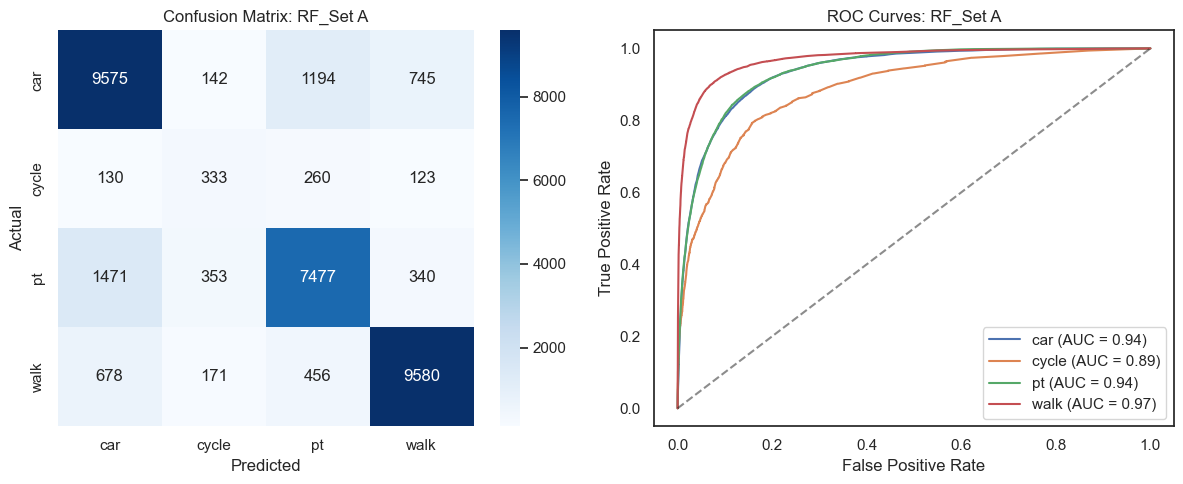


 Currently optimising and training: Set B
Per-class recall: {'car': 0.816, 'cycle': 0.362, 'pt': 0.765, 'walk': 0.875}

 RF_Set B Final Evaluation Report
1. Accuracy (ACC):           0.8091
2. F1-macro:                 0.6964
3. Cohen's Kappa (CK):       0.7203
4. Neg Log Likelihood (NLL): 0.5426
5. Geometric Mean (G-Mean):  0.6668


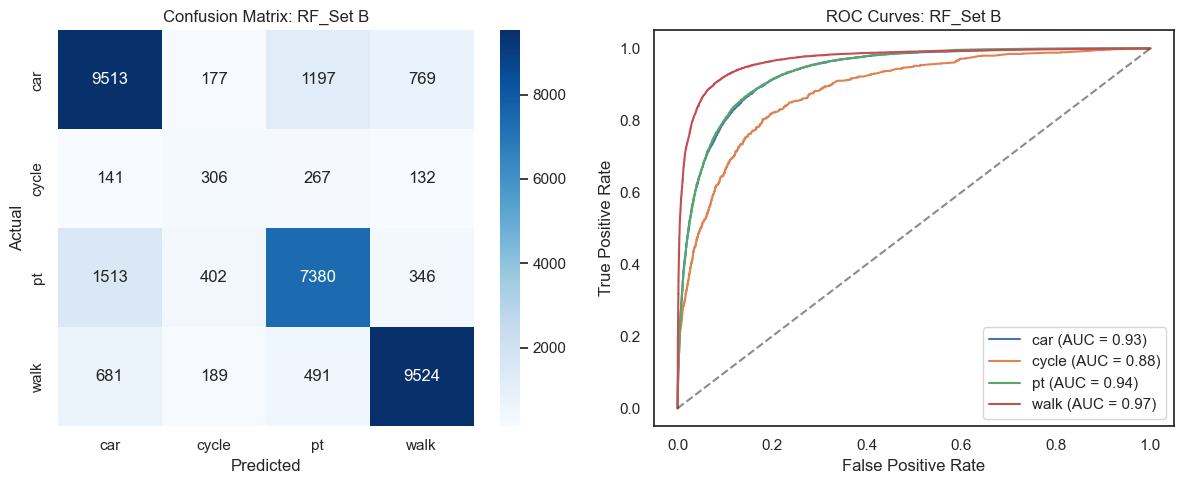


 Currently optimising and training: Set C
Per-class recall: {'car': 0.818, 'cycle': 0.402, 'pt': 0.782, 'walk': 0.882}

 RF_Set C Final Evaluation Report
1. Accuracy (ACC):           0.8177
2. F1-macro:                 0.7127
3. Cohen's Kappa (CK):       0.7329
4. Neg Log Likelihood (NLL): 0.5367
5. Geometric Mean (G-Mean):  0.6899


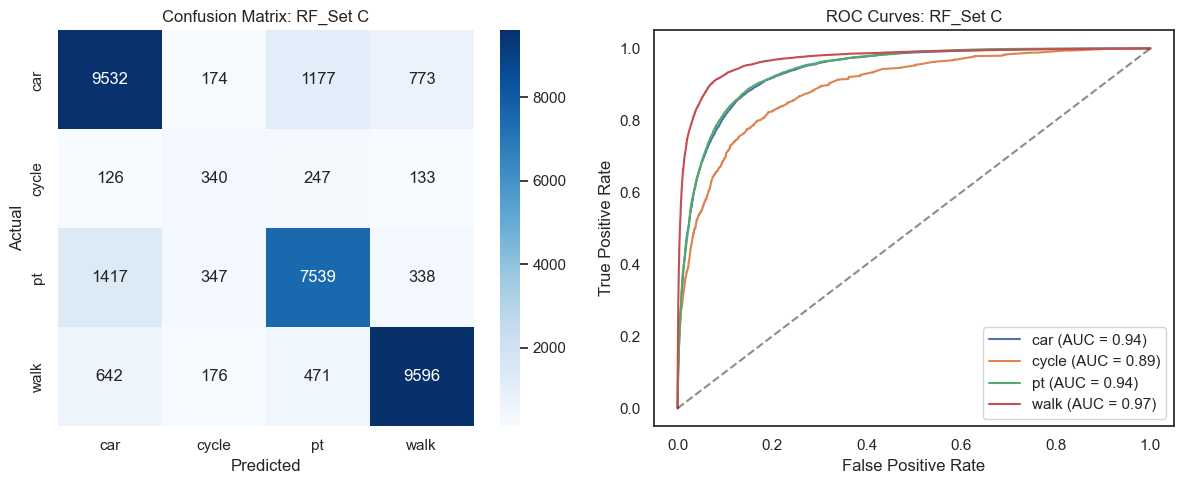


 Final Experiment Summary Table 
Scenario    ACC     F1    NLL     CK  G-Mean
RF_Set A 0.8164 0.7114 0.5323 0.7308  0.6854
RF_Set B 0.8091 0.6964 0.5426 0.7203  0.6668
RF_Set C 0.8177 0.7127 0.5367 0.7329  0.6899


In [10]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'max_depth': [15, 30],
    'n_estimators': [100, 200],
    'class_weight': [None, 'balanced'],
    'max_features': ['sqrt', 'log2']
}

scenarios = {
    'Set A': (X_train_set_A, X_val_set_A, X_test_set_A),
    'Set B': (X_train_set_B, X_val_set_B, X_test_set_B),
    'Set C': (X_train_C,     X_val_C,     X_test_C)
}

for name in SET_NAMES:
    X_train_current, X_val_current, X_test_current = scenarios[name]

    print(f"\n Currently optimising and training: {name}")
    
    rs = RandomizedSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        param_distributions=param_dist,
        n_iter=8, cv=3, scoring='f1_macro', random_state=42, verbose=0
    )
    
    rs.fit(X_train_current, y_train_res)
    best_model = rs.best_estimator_
    
    metrics = full_evaluate_model(
        best_model, X_test_current, y_test_le,
        classes=le_y.classes_, model_name=f"RF_{name}"
    )
    
    unique_key = f"RF_{name}"
    all_results[unique_key] = metrics
    all_best_params[unique_key] = rs.best_params_
    all_probs[unique_key] = best_model.predict_proba(X_test_current)
    all_preds[unique_key] = best_model.predict(X_test_current)

# Generate a summary table
final_comparison = pd.DataFrame.from_dict(all_results, orient='index')
final_comparison.index.name = 'Scenario'
final_comparison.reset_index(inplace=True)

print("\n" + "="*60)
print(" Final Experiment Summary Table ")
print("="*60)
print(final_comparison.to_string(index=False, float_format=lambda x: "{:.4f}".format(x)))

 Starting XGBoost Competition across all Sets...

[XGBoost] Currently optimising and training: Set A
Per-class recall: {'car': 0.83, 'cycle': 0.397, 'pt': 0.788, 'walk': 0.887}

 XGBoost_Set A Final Evaluation Report
1. Accuracy (ACC):           0.8254
2. F1-macro:                 0.7213
3. Cohen's Kappa (CK):       0.7437
4. Neg Log Likelihood (NLL): 0.4885
5. Geometric Mean (G-Mean):  0.6928


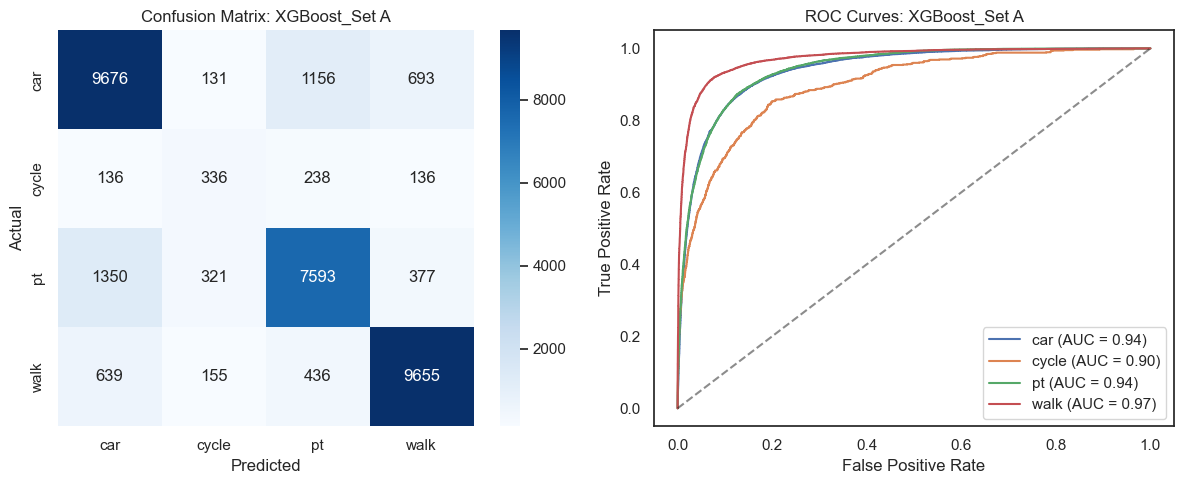


[XGBoost] Currently optimising and training: Set B
Per-class recall: {'car': 0.83, 'cycle': 0.422, 'pt': 0.784, 'walk': 0.885}

 XGBoost_Set B Final Evaluation Report
1. Accuracy (ACC):           0.8244
2. F1-macro:                 0.7198
3. Cohen's Kappa (CK):       0.7428
4. Neg Log Likelihood (NLL): 0.4815
5. Geometric Mean (G-Mean):  0.7022


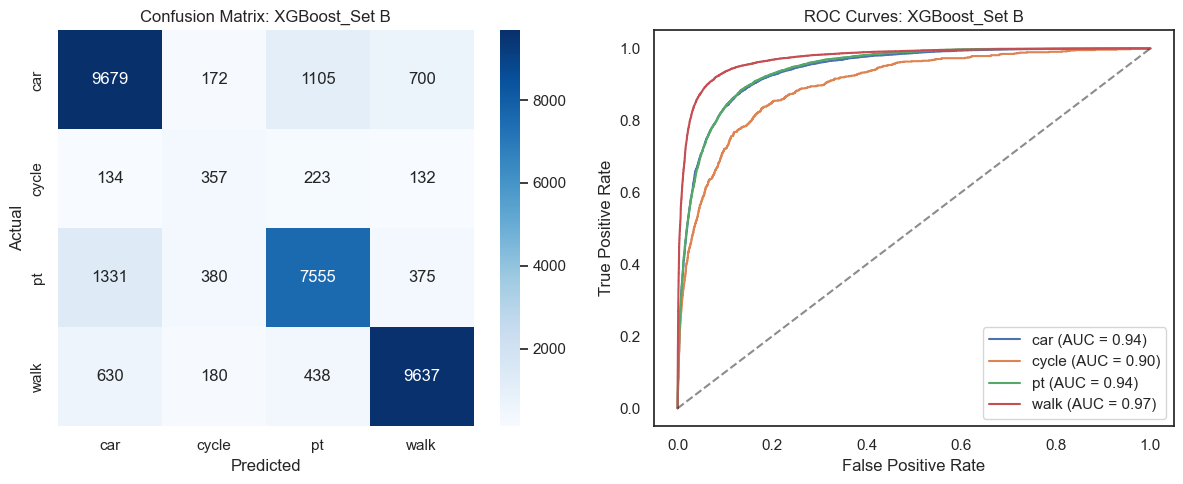


[XGBoost] Currently optimising and training: Set C
Per-class recall: {'car': 0.831, 'cycle': 0.459, 'pt': 0.794, 'walk': 0.889}

 XGBoost_Set C Final Evaluation Report
1. Accuracy (ACC):           0.8298
2. F1-macro:                 0.7335
3. Cohen's Kappa (CK):       0.7506
4. Neg Log Likelihood (NLL): 0.4800
5. Geometric Mean (G-Mean):  0.7202


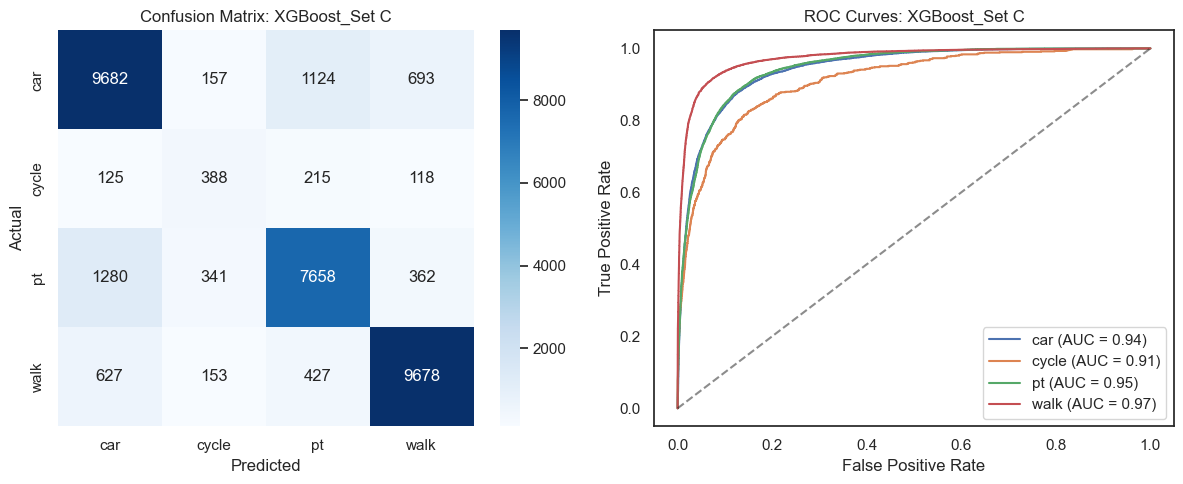


 XGBOOST FINAL EXPERIMENT SUMMARY TABLE 
 Scenario    ACC     F1    NLL     CK  G-Mean
 RF_Set A 0.8164 0.7114 0.5323 0.7308  0.6854
 RF_Set B 0.8091 0.6964 0.5426 0.7203  0.6668
 RF_Set C 0.8177 0.7127 0.5367 0.7329  0.6899
XGB_Set A 0.8254 0.7213 0.4885 0.7437  0.6928
XGB_Set B 0.8244 0.7198 0.4815 0.7428  0.7022
XGB_Set C 0.8298 0.7335 0.4800 0.7506  0.7202


In [11]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
import pandas as pd

xgb_param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [6, 10, 15],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'gamma': [0, 0.1]
}

scenarios = {
    'Set A': (X_train_set_A, X_val_set_A, X_test_set_A),
    'Set B': (X_train_set_B, X_val_set_B, X_test_set_B),
    'Set C': (X_train_C,     X_val_C,     X_test_C)
}

print(" Starting XGBoost Competition across all Sets...")

for name in SET_NAMES:
    X_train_current, X_val_current, X_test_current = scenarios[name]
    
    print(f"\n[XGBoost] Currently optimising and training: {name}")
    
    base_xgb = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(le_y.classes_),
        tree_method='hist',
        random_state=42,
        n_jobs=-1
    )
    
    rs = RandomizedSearchCV(
        base_xgb,
        param_distributions=xgb_param_dist,
        n_iter=8, 
        cv=3, 
        scoring='f1_macro',
        random_state=42, 
        verbose=0
    )
    
    rs.fit(X_train_current, y_train_res)
    best_model = rs.best_estimator_
    

    metrics = full_evaluate_model(
        best_model, X_test_current, y_test_le, 
        classes=le_y.classes_, model_name=f"XGBoost_{name}"
    )
    
    unique_key = f"XGB_{name}" 
    all_results[unique_key] = metrics
    all_best_params[unique_key] = rs.best_params_
    all_probs[unique_key] = best_model.predict_proba(X_test_current)
    all_preds[unique_key] = best_model.predict(X_test_current)

# Generate a summary table
final_comparison_xgb = pd.DataFrame.from_dict(all_results, orient='index')
final_comparison_xgb.index.name = 'Scenario'
final_comparison_xgb.reset_index(inplace=True)

pd.options.display.float_format = '{:.4f}'.format
print("\n" + "="*60)
print(" XGBOOST FINAL EXPERIMENT SUMMARY TABLE ")
print("="*60)
print(final_comparison_xgb.to_string(index=False))

Starting DNN training across all Sets...

[DNN] Processing: Set A | Input dim: 14
Per-class recall: {'car': 0.944, 'cycle': 0.121, 'pt': 0.244, 'walk': 0.561}

 DNN_Set A Final Evaluation Report
1. Accuracy (ACC):           0.5925
2. F1-macro:                 0.4566
3. Cohen's Kappa (CK):       0.3878
4. Neg Log Likelihood (NLL): 0.9828
5. Geometric Mean (G-Mean):  0.3533


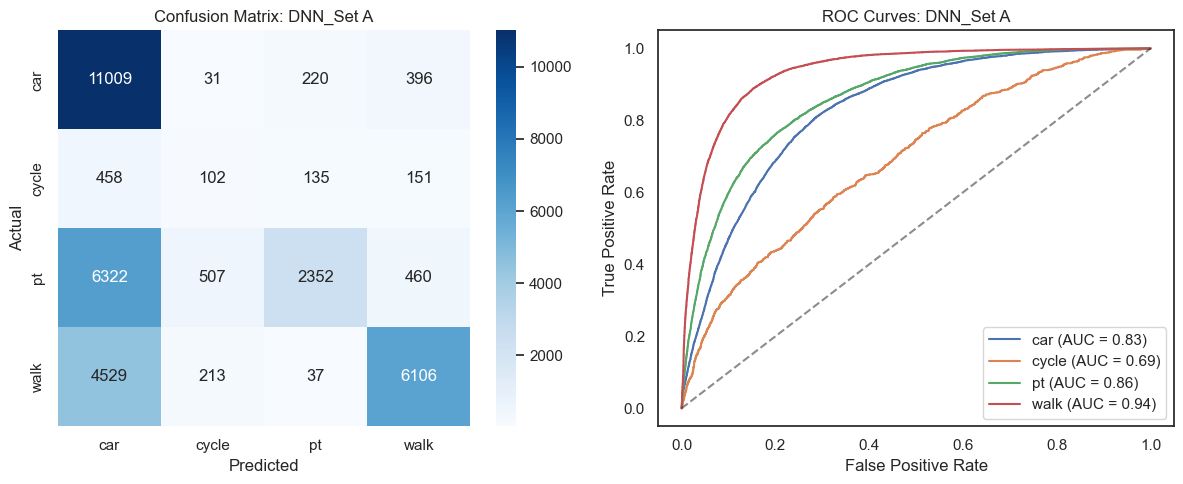


[DNN] Processing: Set B | Input dim: 51
Per-class recall: {'car': 0.727, 'cycle': 0.34, 'pt': 0.64, 'walk': 0.827}

 DNN_Set B Final Evaluation Report
1. Accuracy (ACC):           0.7247
2. F1-macro:                 0.6058
3. Cohen's Kappa (CK):       0.6040
4. Neg Log Likelihood (NLL): 0.6830
5. Geometric Mean (G-Mean):  0.6016


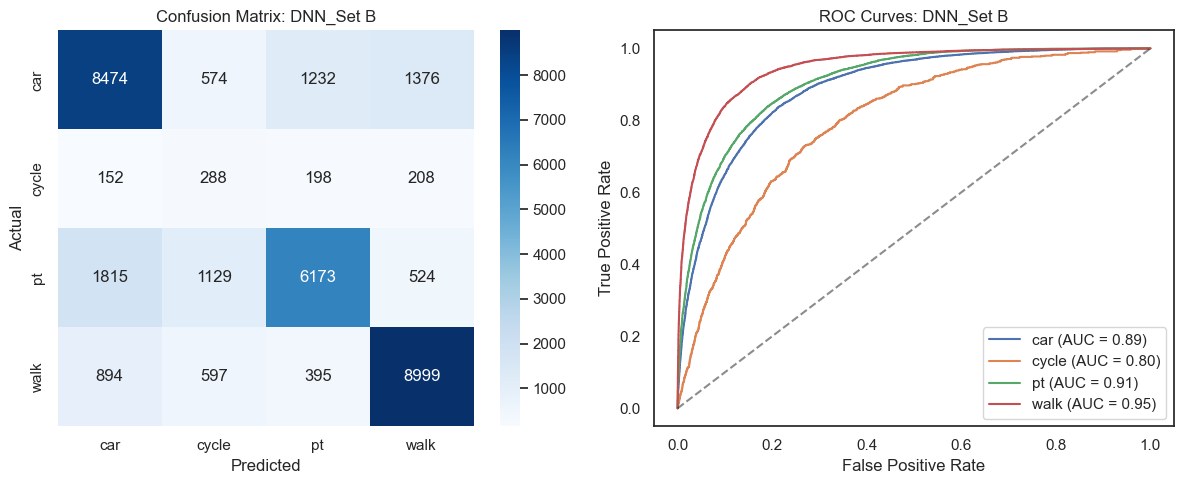


[DNN] Processing: Set C | Input dim: 41
Per-class recall: {'car': 0.732, 'cycle': 0.348, 'pt': 0.651, 'walk': 0.824}

 DNN_Set C Final Evaluation Report
1. Accuracy (ACC):           0.7289
2. F1-macro:                 0.6109
3. Cohen's Kappa (CK):       0.6093
4. Neg Log Likelihood (NLL): 0.6650
5. Geometric Mean (G-Mean):  0.6078


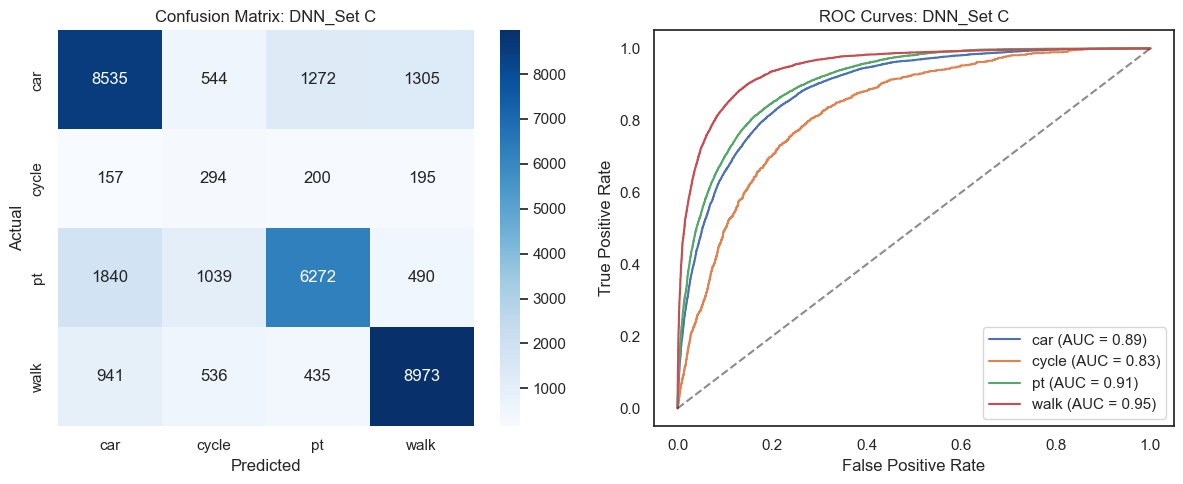


 DNN Final Experiment Summary Table 
 Scenario    ACC     F1    NLL     CK  G-Mean
DNN_Set A 0.5925 0.4566 0.9828 0.3878  0.3533
DNN_Set B 0.7247 0.6058 0.6830 0.6040  0.6016
DNN_Set C 0.7289 0.6109 0.6650 0.6093  0.6078


In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

scenarios = {
    'Set A': (X_train_set_A, X_val_set_A, X_test_set_A), 
    'Set B': (X_train_set_B, X_val_set_B, X_test_set_B),
    'Set C': (X_train_C,     X_val_C,     X_test_C)
}

def build_simple_dnn(input_dim, num_classes, name):
    inputs = Input(shape=(input_dim,), name=f"input_{name}")
    
    x = Dense(256, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.4)(x)
    
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=inputs, outputs=outputs, name=f"DNN_{name}")

print("Starting DNN training across all Sets...")

for name in SET_NAMES:
    tf.keras.backend.clear_session()

    X_train_current, X_val_current, X_test_current = scenarios[name]
    
    print(f"\n[DNN] Processing: {name} | Input dim: {X_train_current.shape[1]}")
    
    input_dim = X_train_current.shape[1]
    num_classes = len(le_y.classes_)
    
    current_dnn = build_simple_dnn(
        input_dim=input_dim,
        num_classes=num_classes,
        name=name.replace(" ", "_")
    )
    
    current_dnn.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    current_dnn.fit(
        X_train_current,
        y_train_res,
        validation_data=(X_val_current, y_val_le),
        epochs=100,
        batch_size=1024,  
        verbose=0,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
        ]
    )
    
    unique_key = f"DNN_{name}"
    
    metrics = full_evaluate_model(
        current_dnn, 
        X_test_current,
        y_test_le, 
        classes=le_y.classes_, 
        model_name=unique_key
    )
    
    all_results[unique_key] = metrics
    all_probs[unique_key] = current_dnn.predict(X_test_current, verbose=0)
    all_preds[unique_key] = np.argmax(all_probs[unique_key], axis=1)
    all_best_params[unique_key] = {"hidden_units": "256-128", "learning_rate": 0.001}

# Generate a summary table
dnn_results_only = {k: v for k, v in all_results.items() if k.startswith('DNN_')}
final_comparison_dnn = pd.DataFrame.from_dict(dnn_results_only, orient='index')
final_comparison_dnn.index.name = 'Scenario'
final_comparison_dnn.reset_index(inplace=True)

pd.options.display.float_format = '{:.4f}'.format
print("\n" + "="*60)
print(" DNN Final Experiment Summary Table ")
print("="*60)
print(final_comparison_dnn.to_string(index=False))

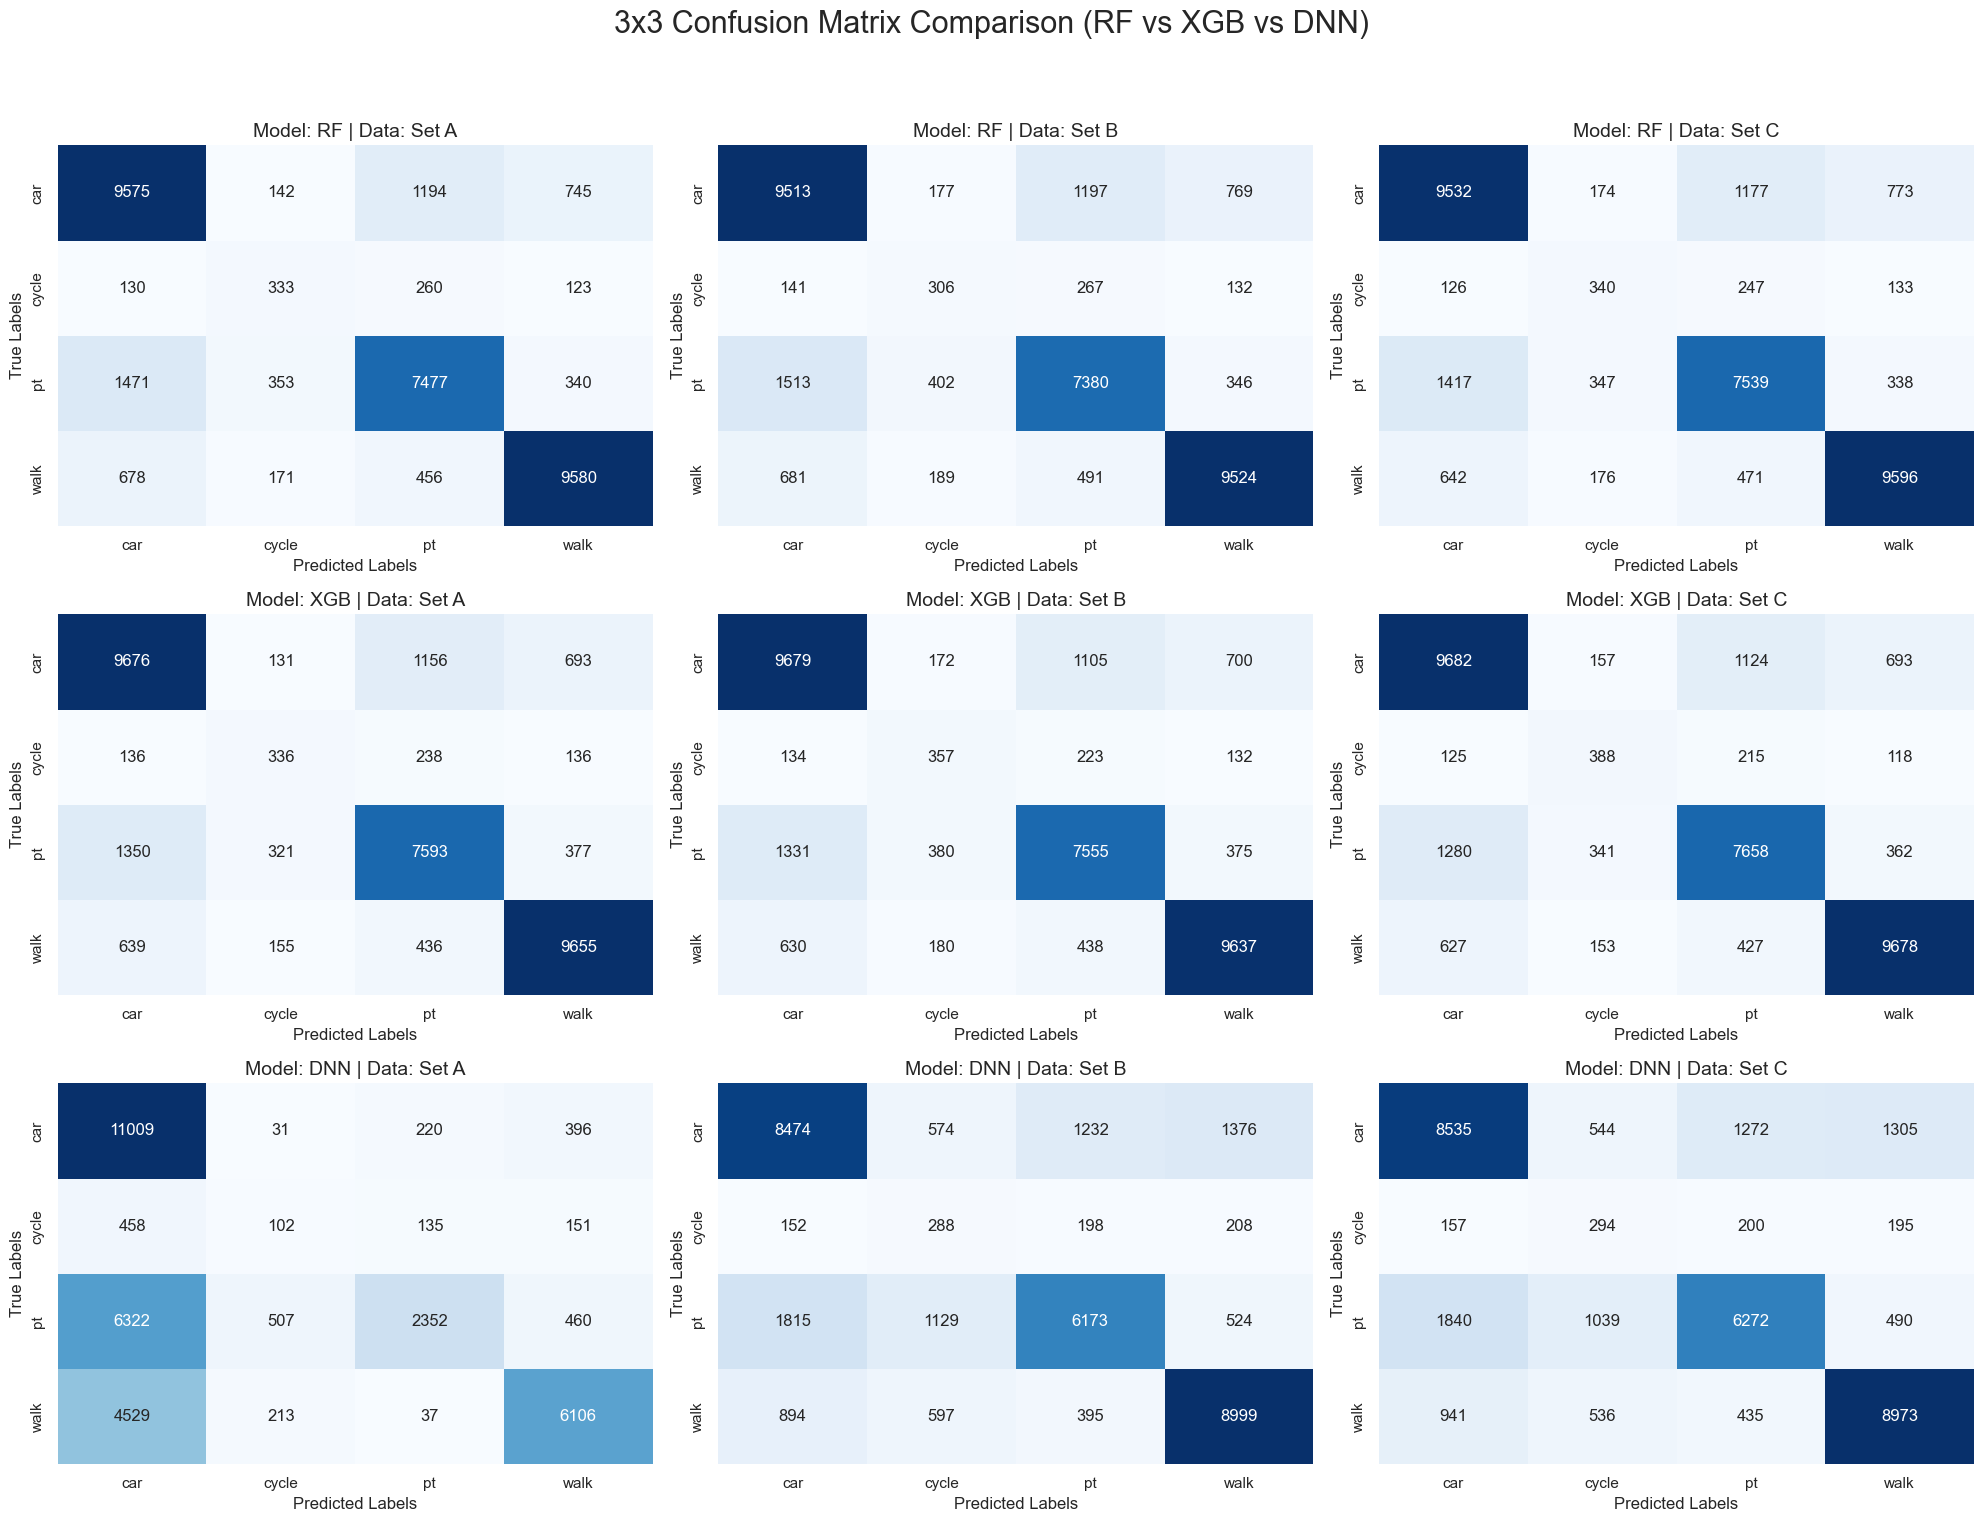

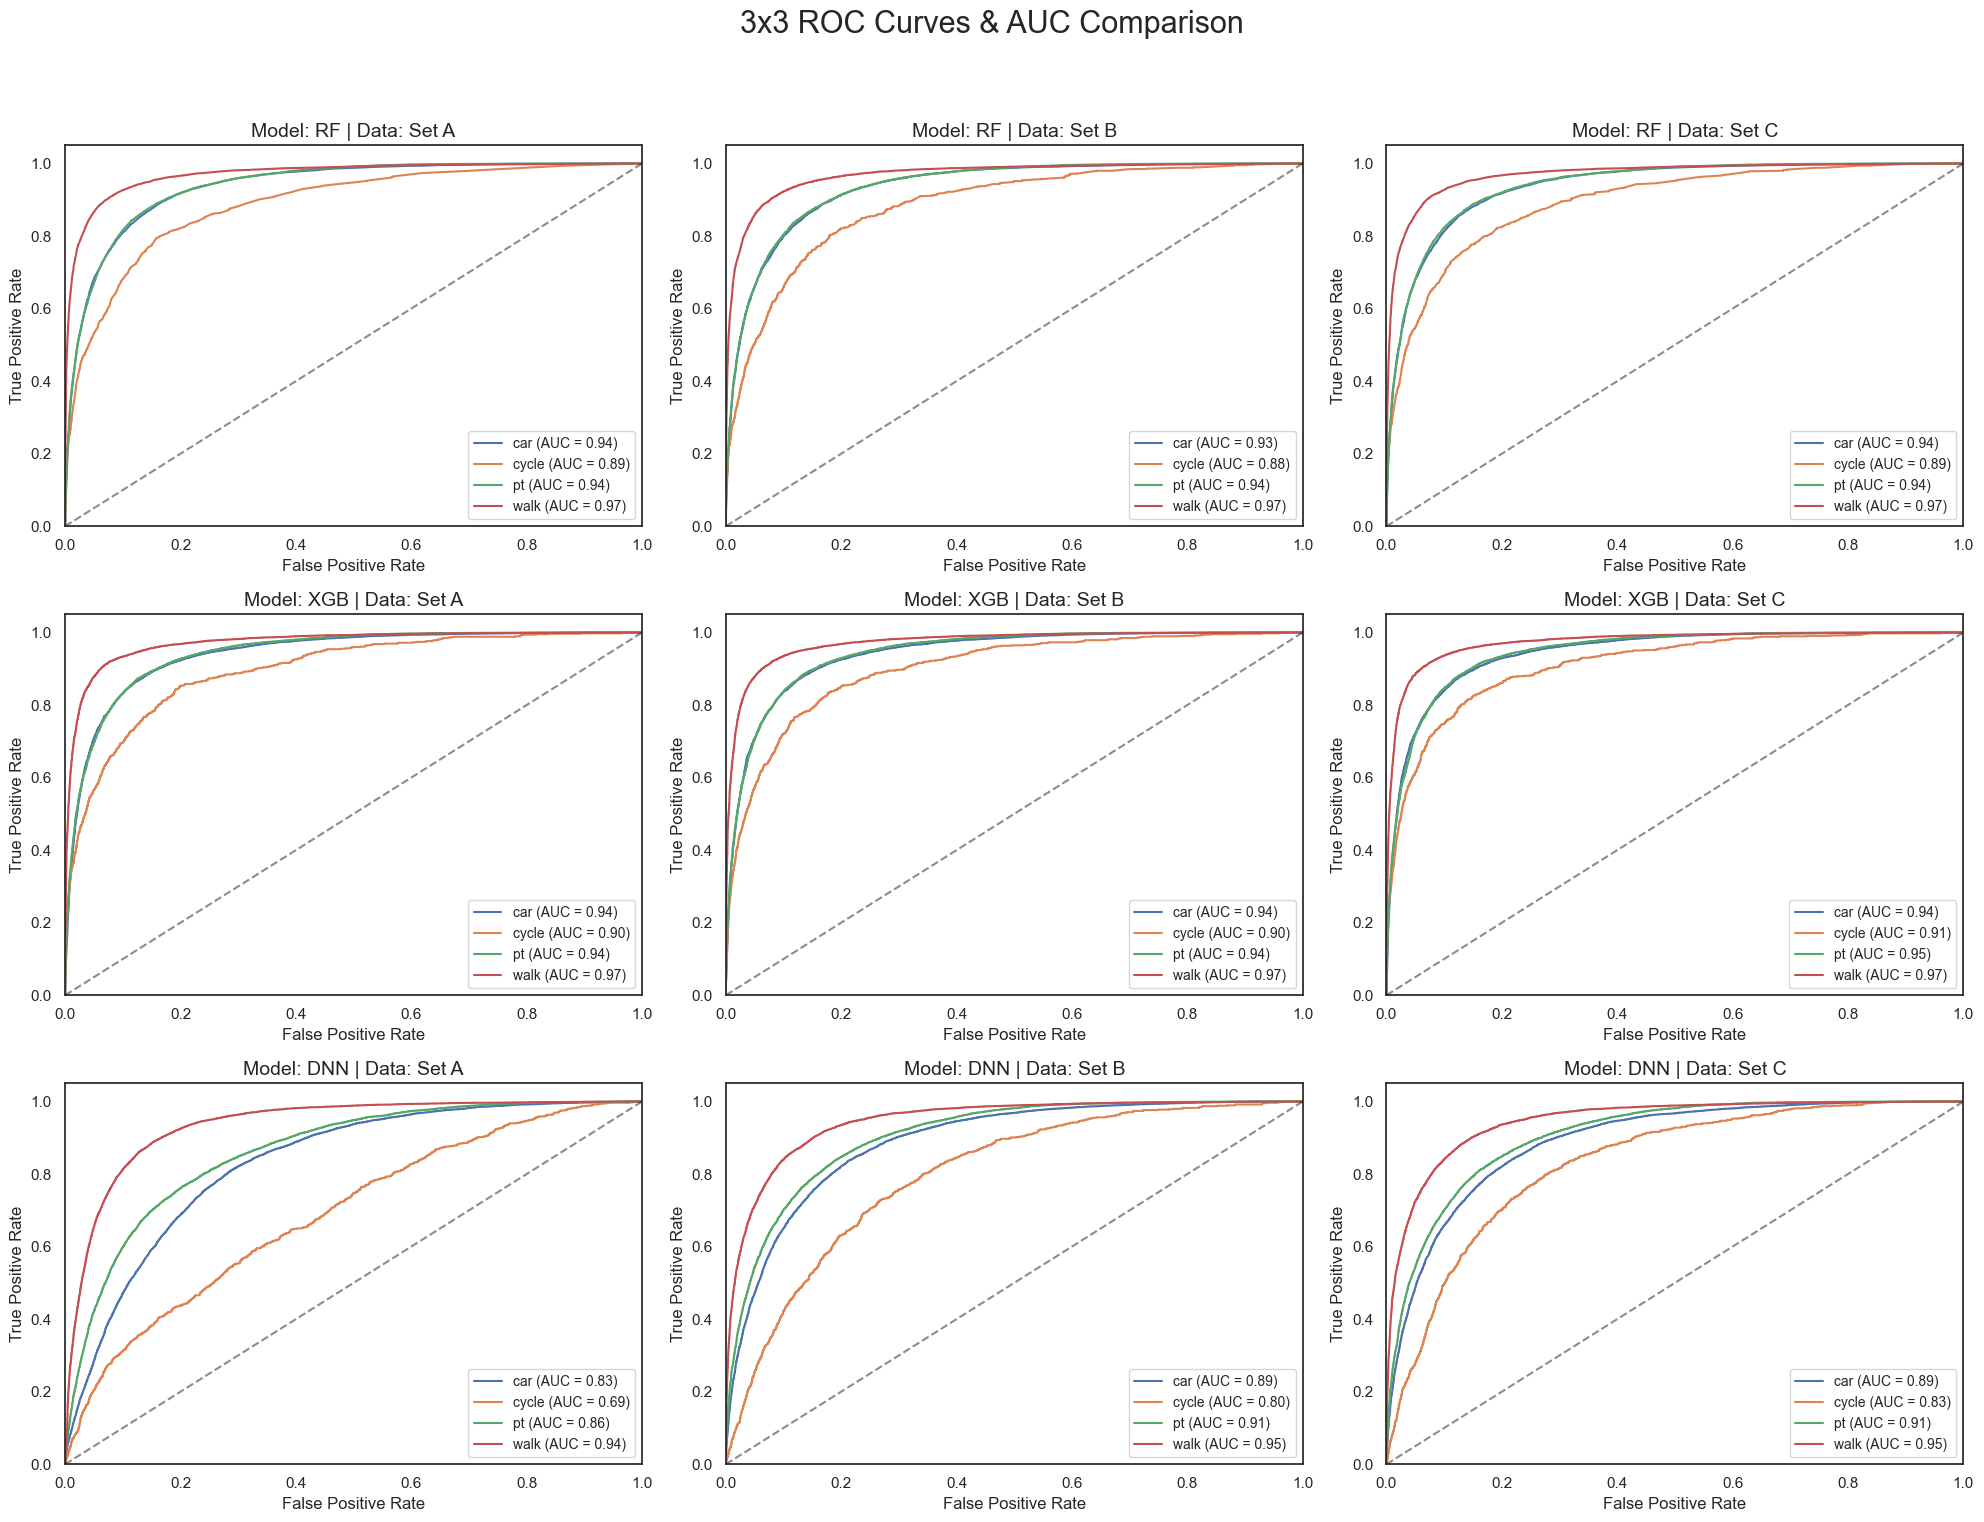


 FINAL MASTER COMPARISON TABLE 
Experiment_Key    ACC     F1    NLL     CK  G-Mean
     XGB_Set C 0.8298 0.7335 0.4800 0.7506  0.7202
     XGB_Set A 0.8254 0.7213 0.4885 0.7437  0.6928
     XGB_Set B 0.8244 0.7198 0.4815 0.7428  0.7022
      RF_Set C 0.8177 0.7127 0.5367 0.7329  0.6899
      RF_Set A 0.8164 0.7114 0.5323 0.7308  0.6854
      RF_Set B 0.8091 0.6964 0.5426 0.7203  0.6668
     DNN_Set C 0.7289 0.6109 0.6650 0.6093  0.6078
     DNN_Set B 0.7247 0.6058 0.6830 0.6040  0.6016
     DNN_Set A 0.5925 0.4566 0.9828 0.3878  0.3533
| Methods | Hyperparameters | Set A (Label) | Set B (One-hot) | Set C (Entity) |
| **RF** | feature_fraction | sqrt | sqrt | sqrt |
|  | max_depth | 30 | 30 | 30 |
|  | tree_number | 200 | 200 | 200 |
|  | class_weight | None | None | None |
| **XGB** | feature_fraction | 1.0 | 1.0 | 1.0 |
|  | max_depth | 15 | 15 | 15 |
|  | min_loss_reduction (gamma) | 0.1 | 0.1 | 0.1 |
|  | learning_rate | 0.1 | 0.1 | 0.1 |
|  | max_training_rounds | 200 | 200 | 200 

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

model_list = ['RF', 'XGB', 'DNN']
set_list = ['Set A', 'Set B', 'Set C']
class_names = le_y.classes_

y_test_bin = label_binarize(y_test_le, classes=range(len(class_names)))
n_classes = len(class_names)

# Confusion matrix
fig_cm, axes_cm = plt.subplots(3, 3, figsize=(20, 16))
fig_cm.suptitle('3x3 Confusion Matrix Comparison (RF vs XGB vs DNN)', fontsize=22)

for i, m_name in enumerate(model_list):
    for j, s_name in enumerate(set_list):
        key = f"{m_name}_{s_name}"
        ax = axes_cm[i, j]
        
        if key in all_preds:
            cm = confusion_matrix(y_test_le, all_preds[key])
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        xticklabels=class_names, yticklabels=class_names, cbar=False)
            ax.set_title(f"Model: {m_name} | Data: {s_name}", fontsize=14)
            ax.set_xlabel('Predicted Labels')
            ax.set_ylabel('True Labels')
        else:
            ax.text(0.5, 0.5, f'Missing Data:\n{key}', ha='center', va='center', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# ROC
fig_roc, axes_roc = plt.subplots(3, 3, figsize=(20, 16))
fig_roc.suptitle('3x3 ROC Curves & AUC Comparison', fontsize=22)

for i, m_name in enumerate(model_list):
    for j, s_name in enumerate(set_list):
        key = f"{m_name}_{s_name}"
        ax = axes_roc[i, j]
        
        if key in all_probs:
            for k in range(n_classes):
                fpr, tpr, _ = roc_curve(y_test_bin[:, k], all_probs[key][:, k])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, label=f'{class_names[k]} (AUC = {roc_auc:.2f})')
            
            ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
            ax.set_xlim([0.0, 1.0])
            ax.set_ylim([0.0, 1.05])
            ax.set_xlabel('False Positive Rate')
            ax.set_ylabel('True Positive Rate')
            ax.set_title(f"Model: {m_name} | Data: {s_name}", fontsize=14)
            ax.legend(loc="lower right", fontsize='small')
        else:
            ax.text(0.5, 0.5, f'Missing Data:\n{key}', ha='center', va='center', fontsize=12)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Summary table
master_results = pd.DataFrame.from_dict(all_results, orient='index')
master_results.index.name = 'Experiment_Key'
master_results.reset_index(inplace=True)

print("\n" + "="*80)
print(" FINAL MASTER COMPARISON TABLE ")
print("="*80)
print(master_results.sort_values(by='F1', ascending=False).to_string(index=False))

# Hyperparameter mapping to standardised table format
def map_params(model_type, params):
    if model_type == 'RF':
        return {
            'feature_fraction':  params.get('max_features', 'sqrt'),
            'max_depth':         params.get('max_depth', 15),
            'tree_number':       params.get('n_estimators', 100),
            'class_weight':      params.get('class_weight', None)
        }
    elif model_type == 'XGB':
        return {
            'feature_fraction':          params.get('colsample_bytree', 1.0),
            'max_depth':                 params.get('max_depth', 6),
            'min_loss_reduction (gamma)':params.get('gamma', 0),
            'learning_rate':             params.get('learning_rate', 0.1),
            'max_training_rounds':       params.get('n_estimators', 100),
            'subsample':                 params.get('subsample', 0.8)
        }
    elif model_type == 'DNN':
        return {
            'hidden layer size':   params.get('hidden_units', '256-128'),
            'number of layers':    params.get('num_layers', 2),
            'learning_rate (Adam)':params.get('learning_rate', 0.001),
            'dropout rate':        params.get('dropout', 0.3)
        }
    return params

# Build formatted params dict
formatted_params = {
    key: map_params(key.split('_')[0], params)
    for key, params in all_best_params.items()
}


# Print Markdown table
def print_param_table(params_dict):
    print("| Methods | Hyperparameters | Set A (Label) | Set B (One-hot) | Set C (Entity) |")

    for model in ['RF', 'XGB', 'DNN']:
        keys = [k for k in params_dict if k.startswith(model)]
        if not keys:
            continue

        param_names = list(params_dict[keys[0]].keys())
        for idx, p_name in enumerate(param_names):
            method_label = f"**{model}**" if idx == 0 else ""
            val_a = params_dict.get(f"{model}_Set A", {}).get(p_name, "-")
            val_b = params_dict.get(f"{model}_Set B", {}).get(p_name, "-")
            val_c = params_dict.get(f"{model}_Set C", {}).get(p_name, "-")
            print(f"| {method_label} | {p_name} | {val_a} | {val_b} | {val_c} |")

print_param_table(formatted_params)

Training completed | Number of features: 41
Mapping total dimensions: 41

Key format example: ['f0', 'f1', 'f2', 'f3', 'f4']
               feature  importance
       journey_purpose     11.8818
                   age     11.4442
            car_access      9.7944
      household_income      6.5370
             ethnicity      6.2184
        working_status      6.1268
trip_start_time_period      4.3280
   household_structure      3.5633
         distance_(km)      3.2354
            disability      1.4598
          road_density      1.4344
     borough_mean_ptal      1.3524
                gender      1.3019
   borough_pop_density      1.0945


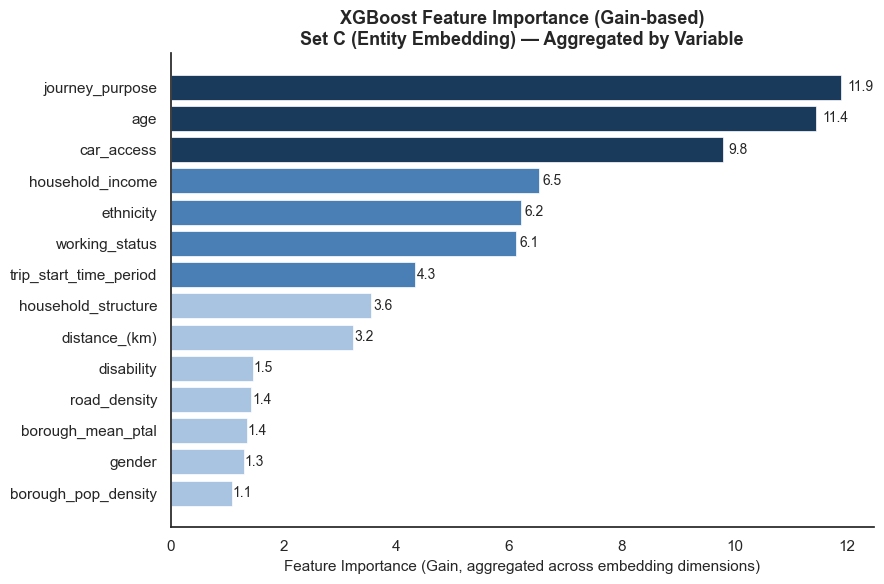

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

# Step 1: Retrain XGBoost Set C
params_clean = {k: v for k, v in all_best_params['XGB_Set C'].items()
                if k != 'use_label_encoder'}

xgb_setC = XGBClassifier(**params_clean, random_state=42,
                          eval_metric='mlogloss', n_jobs=-1)

xgb_setC.fit(X_train_C, y_train_res)
print(f"Training completed | Number of features: {X_train_C.shape[1]}") 


# Step 2:Construct a mapping from 41-dimensional space to the original variable names
emb_config = [
    ('journey_purpose',        6),
    ('trip_start_time_period', 3),
    ('gender',                 1),
    ('car_access',             1),
    ('working_status',         3),
    ('household_income',       6),
    ('disability',             1),
    ('ethnicity',              3),
    ('household_structure',    3),
    ('age',                   10),
]
num_features = ['distance_(km)', 'borough_mean_ptal', 'borough_pop_density', 'road_density']

# Generate the original variable names corresponding to the indices of each dimension
idx_to_varname = {}
idx = 0
for var, dim in emb_config:
    for _ in range(dim):
        idx_to_varname[idx] = var
        idx += 1
for var in num_features:
    idx_to_varname[idx] = var
    idx += 1

print(f"Mapping total dimensions: {len(idx_to_varname)}") 


# Step 3: Extract 'Gain importance' and aggregate by variable
importance_dict = xgb_setC.get_booster().get_score(importance_type='gain')
print(f"\nKey format example: {list(importance_dict.keys())[:5]}")

aggregated = {}
for k, v in importance_dict.items():
    raw = k.replace('f', '') if k.startswith('f') else k
    try:
        feat_idx = int(raw)
    except ValueError:
        print(f"Unable to resolve key: {k},Skip")
        continue

    var_name = idx_to_varname.get(feat_idx, f'unknown_{feat_idx}')
    aggregated[var_name] = aggregated.get(var_name, 0) + v

# Fill in variables with a priority of 0 (not selected for splitting)
all_var_names = [v for v, _ in emb_config] + num_features
for name in all_var_names:
    if name not in aggregated:
        aggregated[name] = 0.0

imp_df = pd.DataFrame({
    'feature': list(aggregated.keys()),
    'importance': list(aggregated.values())
}).sort_values('importance', ascending=False).reset_index(drop=True)


print(imp_df.to_string(index=False))


# Step 4: visualisation
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#1a3a5c' if i < 3 else '#4a7fb5' if i < 7 else '#a8c4e0'
          for i in range(len(imp_df))]

bars = ax.barh(imp_df['feature'], imp_df['importance'],
               color=colors, edgecolor='white', linewidth=0.5)

ax.invert_yaxis()
ax.set_xlabel('Feature Importance (Gain, aggregated across embedding dimensions)',
              fontsize=11)
ax.set_title('XGBoost Feature Importance (Gain-based)\n'
             'Set C (Entity Embedding) — Aggregated by Variable',
             fontsize=13, fontweight='bold')

for bar, val in zip(bars, imp_df['importance']):
    ax.text(val * 1.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}', va='center', fontsize=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('feature_importance_xgb_setC_aggregated.png', dpi=150, bbox_inches='tight')
plt.show()

emb_config Sum of dimensions: 37
num_features dimension:       4
Overall theoretical dimension: 41
Actual X_test_C dimension:     41
Sample shape: (2000, 41)
shap_values type:  <class 'list'>
shap_values shape: (4, 2000, 41)
Aggregated SHAP shape per class: (2000, 14)


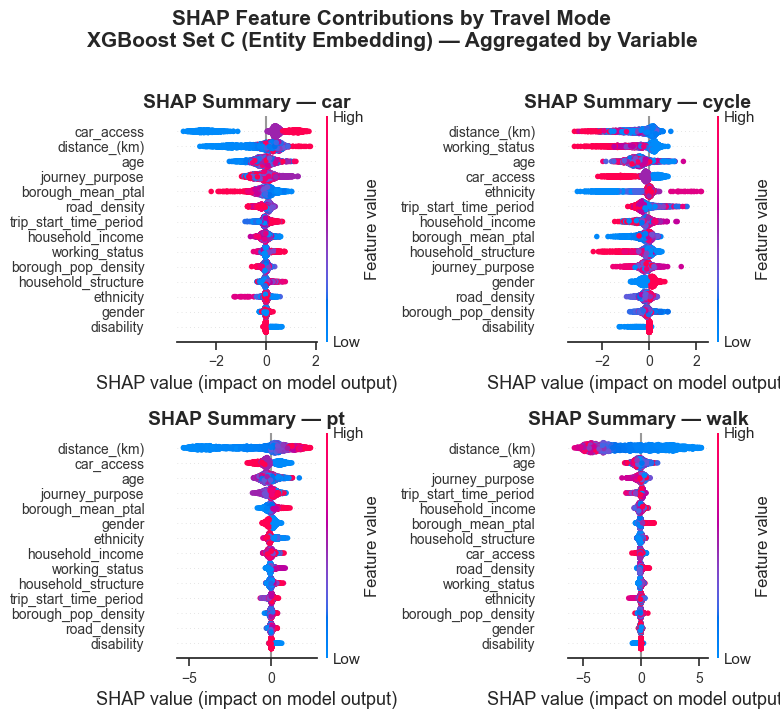

In [21]:
import shap
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Step 1: Prepare the data
feature_names_14 = [
    'distance_(km)',
    'journey_purpose',
    'trip_start_time_period',
    'gender',
    'age',
    'car_access',
    'working_status',
    'household_income',
    'disability',
    'ethnicity',
    'household_structure',
    'borough_mean_ptal',
    'borough_pop_density',
    'road_density'
]

emb_config = [
    ('journey_purpose',        6),
    ('trip_start_time_period', 3),
    ('gender',                 1),
    ('car_access',             1),
    ('working_status',         3),
    ('household_income',       6),
    ('disability',             1),
    ('ethnicity',              3),
    ('household_structure',    3),
    ('age',                   10),
]
num_features = ['distance_(km)', 'borough_mean_ptal', 'borough_pop_density', 'road_density']

# Dimension check
total_dims = sum(dim for _, dim in emb_config) + len(num_features)
print(f"emb_config Sum of dimensions: {sum(dim for _, dim in emb_config)}")
print(f"num_features dimension:       {len(num_features)}")
print(f"Overall theoretical dimension: {total_dims}")
print(f"Actual X_test_C dimension:     {X_test_C.shape[1]}")
assert total_dims == X_test_C.shape[1], \
    f"Dimension mismatch! Theory {total_dims} vs actual {X_test_C.shape[1]}"

# Build 41-dim feature names
all_feature_names_41 = []
for var, dim in emb_config:
    for d in range(dim):
        all_feature_names_41.append(f'{var}_emb{d}')
all_feature_names_41 += num_features

# Sample 2000 from test set
X_test_C_df = pd.DataFrame(X_test_C, columns=all_feature_names_41)
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_C_df), 2000, replace=False)
X_sample = X_test_C_df.iloc[sample_idx].reset_index(drop=True)
print(f"Sample shape: {X_sample.shape}")


# Step 2: Calculate SHAP
explainer = shap.TreeExplainer(
    xgb_setC, 
    feature_perturbation="interventional",
    model_output="raw"
)
shap_values = explainer.shap_values(X_sample)

print(f"shap_values type:  {type(shap_values)}")
print(f"shap_values shape: {np.array(shap_values).shape}")

# Step 3: Aggregate 41-dim SHAP back to 14 original variables
idx_to_varname = {}
idx = 0
for var, dim in emb_config:
    for _ in range(dim):
        idx_to_varname[idx] = var
        idx += 1
for var in num_features:
    idx_to_varname[idx] = var
    idx += 1

def aggregate_shap_to_14(shap_matrix):
    """Aggregate (n, 41) SHAP matrix into (n, 14) by original variable"""
    agg = {name: np.zeros(shap_matrix.shape[0]) for name in feature_names_14}
    for col_idx in range(shap_matrix.shape[1]):
        var_name = idx_to_varname.get(col_idx, None)
        if var_name and var_name in agg:
            agg[var_name] += shap_matrix[:, col_idx]
    return np.column_stack([agg[name] for name in feature_names_14])

# Handle both old (list) and new (ndarray) shap formats
if isinstance(shap_values, list):
    shap_agg = [aggregate_shap_to_14(sv) for sv in shap_values]
else:
    n_classes = shap_values.shape[2]
    shap_agg = [aggregate_shap_to_14(shap_values[:, :, i]) for i in range(n_classes)]

print(f"Aggregated SHAP shape per class: {shap_agg[0].shape}")  # Should be (2000, 14)


X_sample_orig = pd.DataFrame(
    X_test_le.iloc[sample_idx][feature_names_14].values,
    columns=feature_names_14
)

# Step 4: Plot 2x2 SHAP Summary Plot
class_names = list(le_y.classes_)  # ['car', 'cycle', 'pt', 'walk']

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

for i, (cls, ax) in enumerate(zip(class_names, axes)):
    plt.sca(ax)
    shap.summary_plot(
        shap_agg[i],
        X_sample_orig,          
        feature_names=feature_names_14,
        plot_type='dot',
        max_display=14,
        show=False,
        color_bar=True
    )
    ax.set_title(f'SHAP Summary — {cls}', fontsize=14, fontweight='bold')
    ax.tick_params(labelsize=10)

plt.suptitle('SHAP Feature Contributions by Travel Mode\n'
             'XGBoost Set C (Entity Embedding) — Aggregated by Variable',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('shap_summary_xgb_setC.png', dpi=150, bbox_inches='tight')
plt.show()

Baseline F1: 0.7141
Progress: 1/41
Progress: 11/41
Progress: 21/41
Progress: 31/41
Progress: 41/41
Done!

Permutation Importance (aggregated to 14 variables):
               feature  importance_mean  importance_std
         distance_(km)           0.3240          0.0067
            car_access           0.1307          0.0115
                   age           0.0795          0.0388
      household_income           0.0480          0.0225
     borough_mean_ptal           0.0347          0.0088
       journey_purpose           0.0336          0.0277
   household_structure           0.0305          0.0096
        working_status           0.0271          0.0163
                gender           0.0212          0.0090
   borough_pop_density           0.0195          0.0067
             ethnicity           0.0154          0.0164
          road_density           0.0148          0.0094
            disability           0.0025          0.0028
trip_start_time_period          -0.0215          0.0089


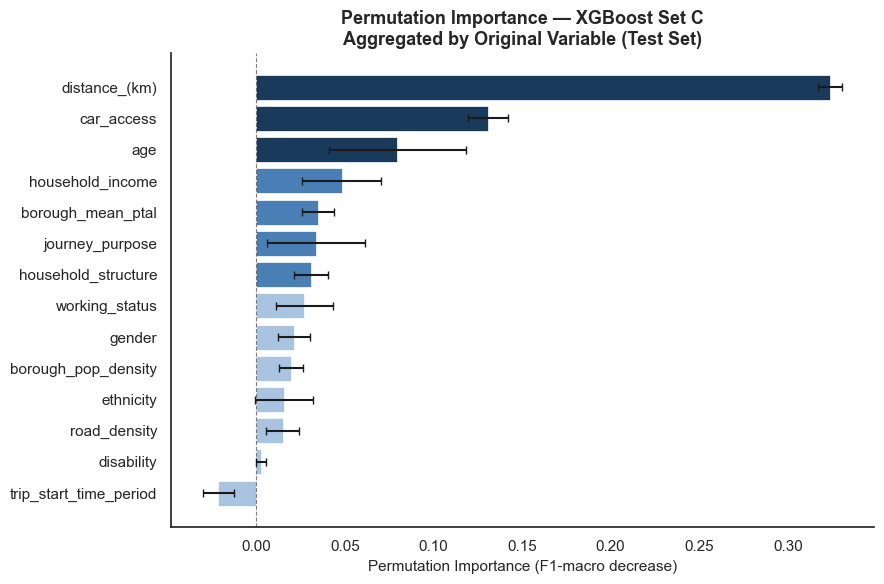

In [16]:
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

# Manual Permutation Importance (avoid joblib multiprocessing)

np.random.seed(42)
sample_idx = np.random.choice(len(X_test_C_df), 2000, replace=False)
X_perm = X_test_C_df.iloc[sample_idx].values
y_perm = y_test_le[sample_idx]

# Baseline score
baseline_pred = xgb_setC.predict(X_perm)
baseline_f1 = f1_score(y_perm, baseline_pred, average='macro')
print(f"Baseline F1: {baseline_f1:.4f}")

# Shuffle each feature one by one and compute importance
n_repeats = 5
importances = []

for col_idx in range(X_perm.shape[1]):
    scores = []
    for _ in range(n_repeats):
        X_permuted = X_perm.copy()
        np.random.shuffle(X_permuted[:, col_idx])  # Shuffle the column
        pred = xgb_setC.predict(X_permuted)
        score = f1_score(y_perm, pred, average='macro')
        scores.append(baseline_f1 - score)  # Larger drop = more important
    importances.append({
        'feature_idx': col_idx,
        'importance_mean': np.mean(scores),
        'importance_std': np.std(scores)
    })
    if col_idx % 10 == 0:
        print(f"Progress: {col_idx+1}/{X_perm.shape[1]}")

print("Done!")

# Aggregate back to 14 original variables
agg_mean = {name: 0.0 for name in feature_names_14}
agg_std  = {name: 0.0 for name in feature_names_14}

for item in importances:
    var_name = idx_to_varname.get(item['feature_idx'], None)
    if var_name and var_name in agg_mean:
        agg_mean[var_name] += item['importance_mean']
        agg_std[var_name]  += item['importance_std']

perm_df = pd.DataFrame({
    'feature':         list(agg_mean.keys()),
    'importance_mean': list(agg_mean.values()),
    'importance_std':  list(agg_std.values())
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

print("\nPermutation Importance (aggregated to 14 variables):")
print(perm_df.to_string(index=False))  

# Visualisation
fig, ax = plt.subplots(figsize=(9, 6))

colors = ['#1a3a5c' if i < 3 else '#4a7fb5' if i < 7 else '#a8c4e0'
          for i in range(len(perm_df))]

ax.barh(perm_df['feature'], perm_df['importance_mean'],
        xerr=perm_df['importance_std'],
        color=colors, edgecolor='white', linewidth=0.5, capsize=3)

ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Permutation Importance (F1-macro decrease)', fontsize=11)
ax.set_title('Permutation Importance — XGBoost Set C\n'
             'Aggregated by Original Variable (Test Set)',
             fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('permutation_importance_xgb_setC.png', dpi=150, bbox_inches='tight')
plt.show()  

xgb_setA trained | classes: [0 1 2 3]


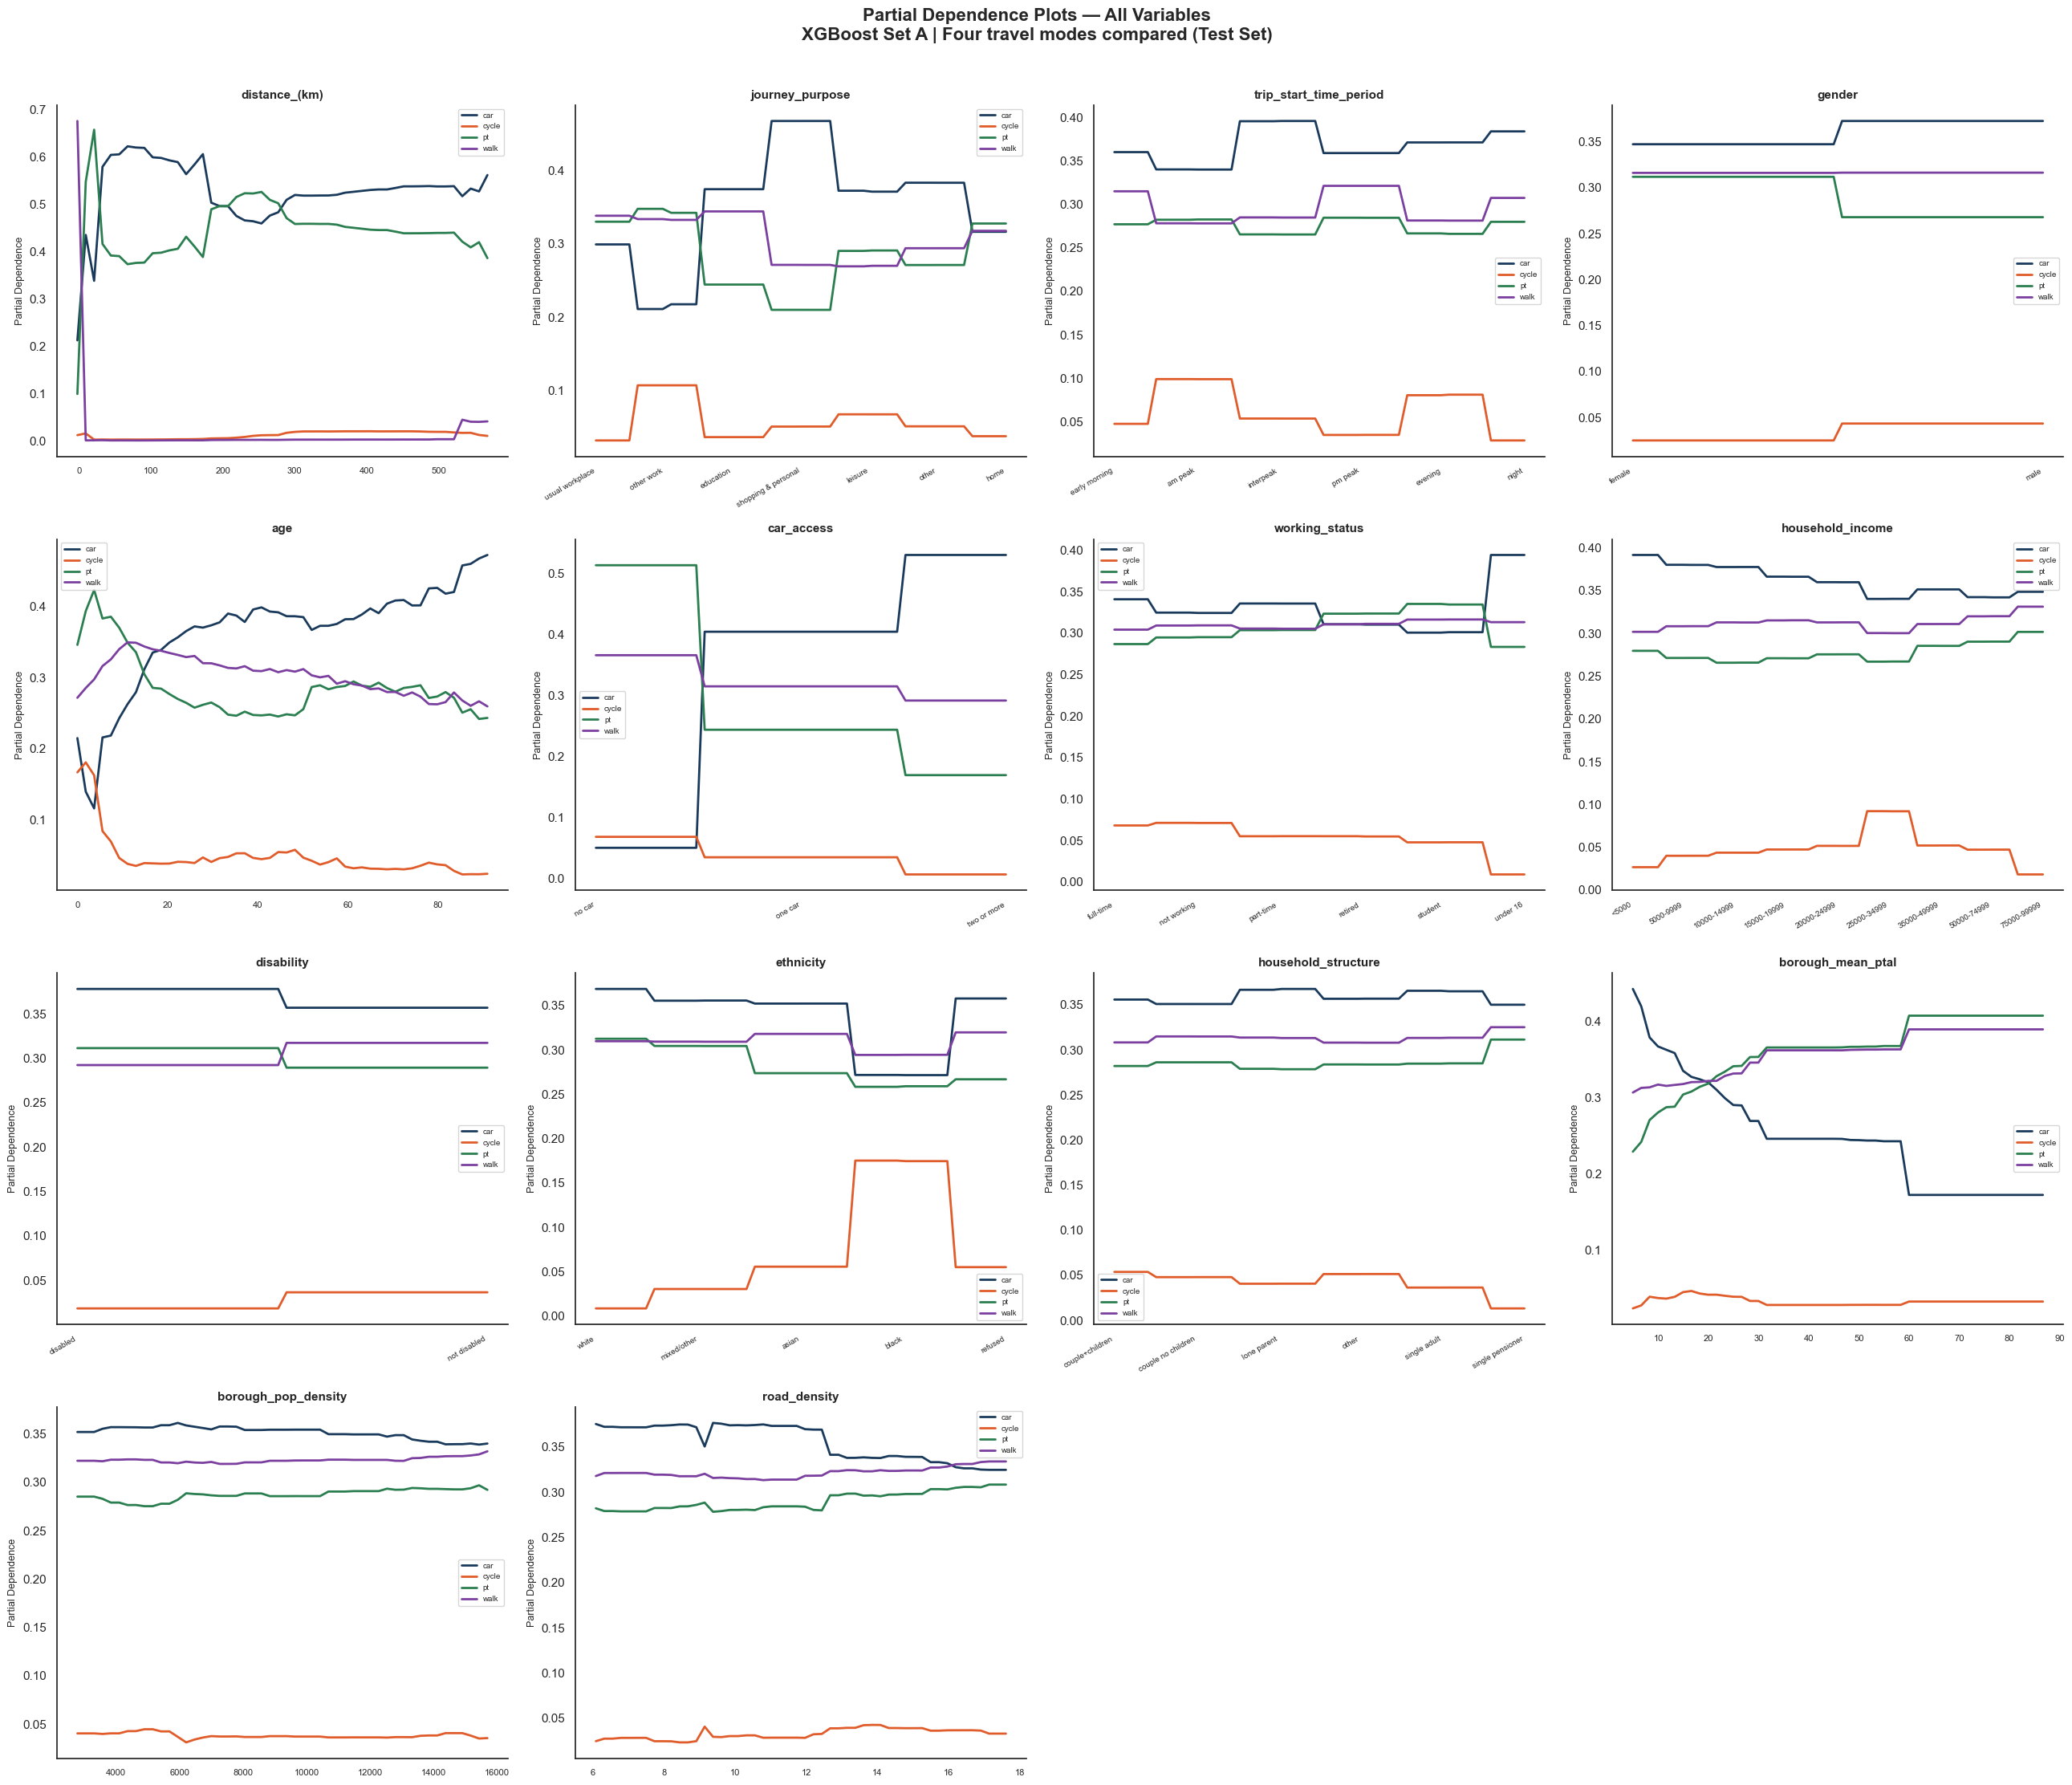

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xgboost as xgb

# Feature names — must match X_train_set_A column order
feature_names_14 = [
    'distance_(km)', 'journey_purpose', 'trip_start_time_period',
    'gender', 'age', 'car_access', 'working_status', 'household_income',
    'disability', 'ethnicity', 'household_structure',
    'borough_mean_ptal', 'borough_pop_density', 'road_density'
]


# Retrain xgb_setA with DataFrame to ensure compatibility
X_train_A_df = pd.DataFrame(X_train_set_A, columns=feature_names_14).astype(float)
X_test_A_df  = pd.DataFrame(X_test_set_A,  columns=feature_names_14).astype(float)

params_setA = {k: v for k, v in all_best_params['XGB_Set A'].items()
               if k != 'use_label_encoder'}
xgb_setA = xgb.XGBClassifier(**params_setA, random_state=42,
                               eval_metric='mlogloss', n_jobs=-1)
xgb_setA.fit(X_train_A_df, y_train_res)
print(f"xgb_setA trained | classes: {xgb_setA.classes_}")

# Category axis labels
category_labels = {
    'journey_purpose': [
        'usual workplace', 'other work', 'education',
        'shopping & personal', 'leisure', 'other', 'home'
    ],
    'trip_start_time_period': [
        'early morning', 'am peak', 'interpeak',
        'pm peak', 'evening', 'night'
    ],
    'gender':    ['female', 'male'],
    'car_access': ['no car', 'one car', 'two or more'],
    'working_status': [
        'full-time', 'not working', 'part-time',
        'retired', 'student', 'under 16'
    ],
    'household_income': [
        '<5000', '5000-9999', '10000-14999', '15000-19999',
        '20000-24999', '25000-34999', '35000-49999',
        '50000-74999', '75000-99999'
    ],
    'disability': ['disabled', 'not disabled'],
    'ethnicity':  ['white', 'mixed/other', 'asian', 'black', 'refused'],
    'household_structure': [
        'couple+children', 'couple no children',
        'lone parent', 'other', 'single adult', 'single pensioner'
    ],
}

class_names = list(le_y.classes_)
colors_mode = ['#1a3a5c', '#e05c2a', '#2a7e4f', '#7b3fa0']

# Manual PDP — bypasses sklearn wrapper incompatibility
# Uses a 500-row sample for speed
def manual_pdp(model, X, feat_idx, grid_resolution=50):
    np.random.seed(42)
    sample = X.sample(min(500, len(X)), random_state=42).reset_index(drop=True)
    grid = np.linspace(
        X.iloc[:, feat_idx].min(),
        X.iloc[:, feat_idx].max(),
        grid_resolution
    )
    avg_preds = []
    for val in grid:
        X_copy = sample.copy()
        X_copy.iloc[:, feat_idx] = val
        probs = model.predict_proba(X_copy)
        avg_preds.append(probs.mean(axis=0))
    return grid, np.array(avg_preds).T  # shape (4, grid_resolution)


# Plot 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(26, 22))
axes = axes.flatten()

for feat_idx, feat_name in enumerate(feature_names_14):
    ax = axes[feat_idx]
    grid_values, avg_array = manual_pdp(xgb_setA, X_test_A_df, feat_idx)

    for class_idx, (cls, col) in enumerate(zip(class_names, colors_mode)):
        ax.plot(grid_values, avg_array[class_idx],
                color=col, linewidth=2, label=cls)
    ax.legend(fontsize=7, loc='best')

    if feat_name in category_labels:
        labels = category_labels[feat_name]
        tick_positions = [round(v) for v in grid_values
                          if 0 <= round(v) < len(labels)]
        tick_positions = sorted(set(tick_positions))
        tick_labels    = [labels[i] for i in tick_positions]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels, rotation=30, ha='right', fontsize=7)
    else:
        ax.tick_params(axis='x', labelsize=8)

    ax.set_title(feat_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Partial Dependence', fontsize=9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[14].set_visible(False)
axes[15].set_visible(False)

plt.suptitle('Partial Dependence Plots — All Variables\n'
             'XGBoost Set A | Four travel modes compared (Test Set)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('pdp_all_variables.png', dpi=150, bbox_inches='tight')
plt.show()

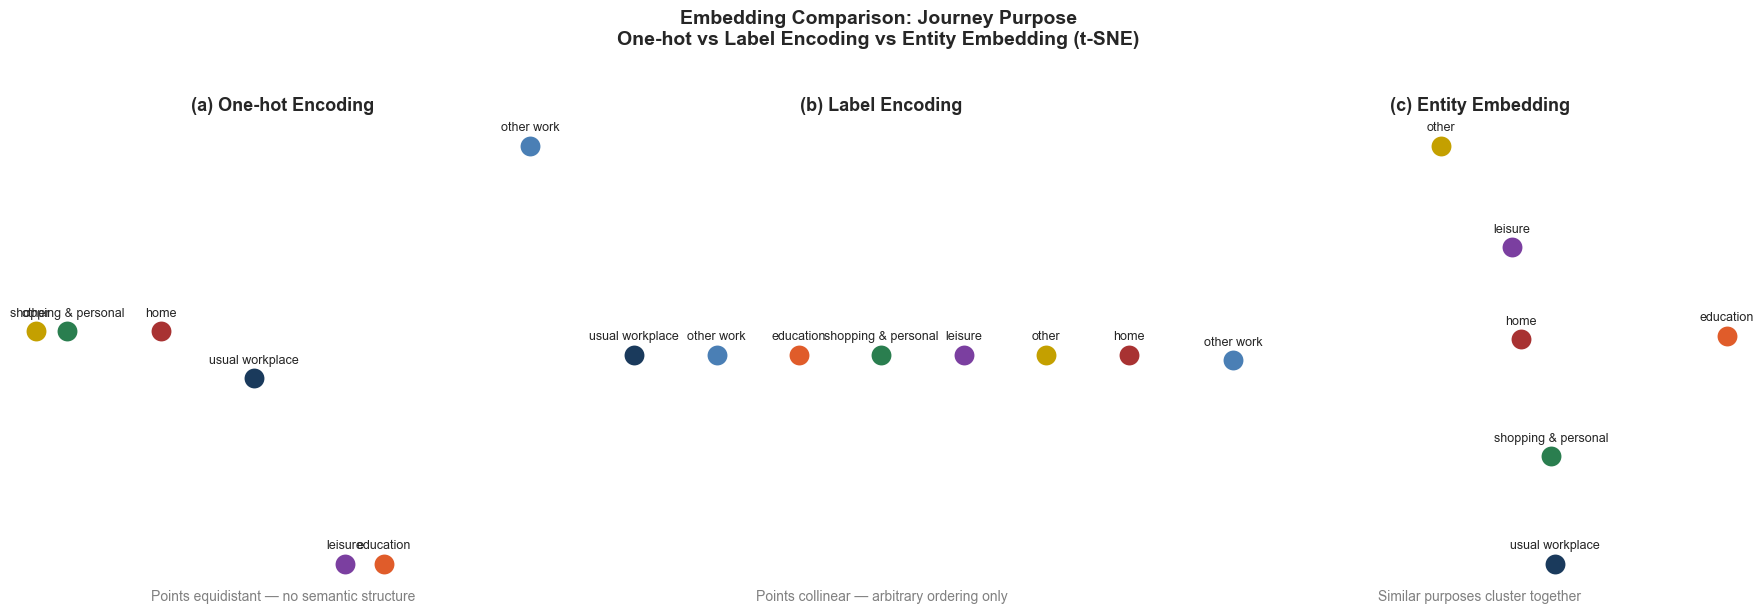

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

# Preparation: the ‘journey_purpose’ label and colour

journey_labels = [
    'usual workplace', 'other work', 'education',
    'shopping & personal', 'leisure', 'other', 'home'
]
n_categories = len(journey_labels)
colors = ['#1a3a5c', '#4a7fb5', '#e05c2a', '#2a7e4f', 
          '#7b3fa0', '#c4a000', '#a83232']


# (a) One-hot encoding → t-SNE
onehot = np.eye(n_categories) 
# The one-hot encoding has only 7 dimensions; the t-SNE perplexity must be less than the number of samples
# Displayed directly using the original 7-dimensional coordinates (all distances are equal)
from sklearn.decomposition import PCA
pca_oh = PCA(n_components=2)
coords_oh = pca_oh.fit_transform(onehot)


# (b) Label encoding 
label_encoded = np.arange(n_categories).reshape(-1, 1).astype(float)
# Add a random noise column to make the PCA meaningful
label_encoded_2d = np.hstack([label_encoded, np.zeros((n_categories, 1))])

# (c) Entity embedding 
emb_weights = final_model.get_layer('emb_journey_purpose').get_weights()[0]
emb_weights = emb_weights[1:] 

# t-SNE (6 dimensions → 2 dimensions)
# With only 7 samples, the perplexity must be less than 7
tsne = TSNE(n_components=2, perplexity=3, random_state=42, 
            max_iter=2000, init='random')
coords_emb = tsne.fit_transform(emb_weights)

# Draw three comparison diagrams
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (coords_oh,        '(a) One-hot Encoding',   
     'Points equidistant — no semantic structure'),
    (label_encoded_2d, '(b) Label Encoding',     
     'Points collinear — arbitrary ordering only'),
    (coords_emb,       '(c) Entity Embedding',   
     'Similar purposes cluster together'),
]

for ax, (coords, title, subtitle) in zip(axes, datasets):
    for i, (label, color) in enumerate(zip(journey_labels, colors)):
        ax.scatter(coords[i, 0], coords[i, 1],
                   color=color, s=250, zorder=5,
                   edgecolors='white', linewidths=1.5)
        ax.annotate(label, coords[i],
                    fontsize=9, ha='center', va='bottom',
                    xytext=(0, 8), textcoords='offset points')

    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel(subtitle, fontsize=10, color='gray')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

plt.suptitle('Embedding Comparison: Journey Purpose\n'
             'One-hot vs Label Encoding vs Entity Embedding (t-SNE)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('embedding_comparison_journey_purpose.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 Discussion

### 7.1 Insights
This study compares encoding strategies and feature types in travel mode prediction and provides several key insights.

First, model choice matters more than encoding strategy. Tree-based models, especially XGBoost, consistently outperform DNN across all metrics, suggesting they are better suited for travel data due to their ability to capture nonlinear relationships and threshold effects.

Second, entity embedding offers only modest improvements. While it enhances DNN performance and slightly improves tree-based models, the gains are limited. This indicates that tree-based models are relatively insensitive to encoding methods, and the main value of embedding lies in learning meaningful representations rather than significantly improving accuracy.

Third, interpretation results consistently show that individual and trip-related variables dominate. Distance and car access are the most influential predictors across all methods, highlighting the importance of mobility constraints and personal resources. In contrast, built environment variables (e.g., PTAL and road density) have weaker effects, suggesting a more indirect role. PDP results further reveal nonlinear and threshold effects, reinforcing the advantage of tree-based models in capturing complex behavioural patterns.


### 7.2 Limitations
Spatial variables are aggregated at the borough level, which may mask local variation. Class imbalance, particularly for cycling, remains a challenge despite SMOTE. The DNN architecture is relatively simple and may not fully exploit embedding potential. Finally, the study focuses on prediction rather than causality.
Overall, the findings emphasise the importance of model selection and feature design, while demonstrating the value of interpretable machine learning in understanding travel behaviour.


## 8 Conclusion

[[ go back to the top ]](#Table-of-contents)

This study examines the impact of encoding strategies and feature types on travel mode prediction in London. Results show that tree-based models, particularly XGBoost, consistently outperform deep neural networks, indicating the importance of model choice over encoding strategy. Although entity embedding offers slight improvements, its overall impact is limited.

Feature interpretation highlights that travel behaviour is mainly driven by individual and trip-related factors, especially distance and car access, while built environment variables provide weaker additional contributions.

Overall, the findings demonstrate that combining robust machine learning models with interpretability techniques can achieve strong predictive performance while offering meaningful behavioural insights. These results provide useful implications for urban transport planning, particularly in promoting more sustainable travel modes.


## 9 References

[[ go back to the top ]](#Table-of-contents)

Fairnie, G.A., Wilby, D.J.R., Saunders, L.E., 2016. Active travel in London: the role of travel survey data in describing population physical activity. J. Transp. Health, Special Issue: Public Transport and Health 3, 161–172. https://doi.org/10.1016/j.jth.2016.02.003
Guo, L., Yang, S., Peng, Y., Yuan, M., 2023. Examining the nonlinear effects of residential and workplace-built environments on active travel in short-distance: a random forest approach. Int. J. Environ. Res. Public. Health 20, 1969. https://doi.org/10.3390/ijerph20031969
Hillel, T., Elshafie, M.Z.E.B., Jin, Y., 2018. Recreating passenger mode choice-sets for transport simulation: a case study of London, UK. Proc. Inst. Civ. Eng. - Smart Infrastruct. Constr. 171, 29–42. https://doi.org/10.1680/jsmic.17.00018
Koushik, A.N., Manoj, M., Nezamuddin, N., Prathosh, A., 2023. Testing and enhancing spatial transferability of artificial neural networks based travel behavior models. Transp. Lett. 15, 1083–1094. https://doi.org/10.1080/19427867.2022.2130150
Ma, Y., Zhang, Z., 2020. Travel mode choice prediction using deep neural networks with entity embeddings. IEEE Access 8, 64959–64970. https://doi.org/10.1109/ACCESS.2020.2985542
TFL, 2018. Mayor’s transport strategy | london city hall [WWW Document]. URL https://www.london.gov.uk/programmes-strategies/transport/our-vision-transport/mayors-transport-strategy-2018 (accessed 5.1.26).
Wang, S., Mo, B., Zhao, J., 2019. Predicting travel mode choice with 86 machine learning 1 classifiers: an empirical benchmark study 2.



## AI Statement
This project used AI tools to assist with code explanation, debugging support and report editing. All analytical decisions, data processing steps, model outputs, interpretations and final written content were reviewed and validated by myself.